# goals
* explore the mismatch between lensed, RP and NP waveforms
* explore the conditions for indistinguishable waveforms

# import modules

In [1]:
import sys

sys.path.insert(0, "../")

import numpy as np

from modules.default_params_v3 import (
    lens_params_1,
    RP_params_1,
    NP_params_1,
    loc_params,
    SOLMASS2SEC,
    GIGAPC2SEC,
)
from modules.functions_v3 import set_orientation
from modules.cosmology import apply_z
from modules.waveform_plotting import *

/opt/anaconda3/envs/gw/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# assign params

In [2]:
from matplotlib.colors import to_hex

n = 3
cmap = plt.get_cmap("jet")
linecolors = [cmap(x) for x in np.linspace(0, 1, n)]
linecolors = [to_hex(c) for c in linecolors]
print(linecolors)
# linecolors = ["#ff00ff", "#00ff00", "#FF0202"]
# linecolors = ["#CC4678", "#0D0887", "#279D00"]
# linecolors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
linecolors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
# linecolors = ["#1f77b4", "#d62728", "#2ca02c"]
linecolors = ["red", "green", "blue"]

['#000080', '#7dff7a', '#800000']


In [3]:
def_td = 0.03
def_I = 0.5
def_y = get_y_from_I(def_I)
def_MLz = get_MLz_from_td(def_td, def_y)
print(f"Default source position y = {def_y:.2f} (I = {def_I})")
print("Default lens mass MLz = {:.3f} solar masses".format(def_MLz))

# Optional cosmological redshift (source-frame -> detector-frame).
z = 0.0001  # set e.g. 0.1 to enable redshifted chirp mass/dist

lens_params_1["y"] = def_y
lens_params_1["MLz"] = def_MLz * SOLMASS2SEC
lens_params_1, RP_params_1, NP_params_1 = set_orientation(
    loc_params["Taman"]["edgeon"], lens_params_1, RP_params_1, NP_params_1
)

print(
    "Chirp mass (source frame) = {:.3f} solar masses".format(
        lens_params_1["mcz"] / SOLMASS2SEC
    )
)

# For reporting, compute detector-frame parameters from copies so helpers can handle z.
if z is not None:
    lens_params_det = apply_z(lens_params_1.copy(), z)
    RP_params_det = apply_z(RP_params_1.copy(), z)
    NP_params_det = apply_z(NP_params_1.copy(), z)
    print(f"Applied redshift z={z} (mcz treated as source-frame)")
    print(
        "Chirp mass (detector frame) = {:.3f} solar masses".format(
            lens_params_det["mcz"] / SOLMASS2SEC
        )
    )
    print(
        "Luminosity distance (detector frame) = {:.3f} Gpc".format(
            lens_params_det["dist"] / GIGAPC2SEC
        )
    )
else:
    print(
        "Chirp mass (detector frame) = {:.3f} solar masses".format(
            lens_params_1["mcz"] / SOLMASS2SEC
        )
    )
    print(
        "Luminosity distance (source frame) = {:.3f} Gpc".format(
            lens_params_1["dist"] / GIGAPC2SEC
        )
    )

Default source position y = 0.35 (I = 0.5)
Default lens mass MLz = 2174.547 solar masses
Chirp mass (source frame) = 20.000 solar masses
Applied redshift z=0.0001 (mcz treated as source-frame)
Chirp mass (detector frame) = 20.002 solar masses
Luminosity distance (detector frame) = 0.000 Gpc


# lensing

Applied redshift z=0.0001 (mcz treated as source-frame)


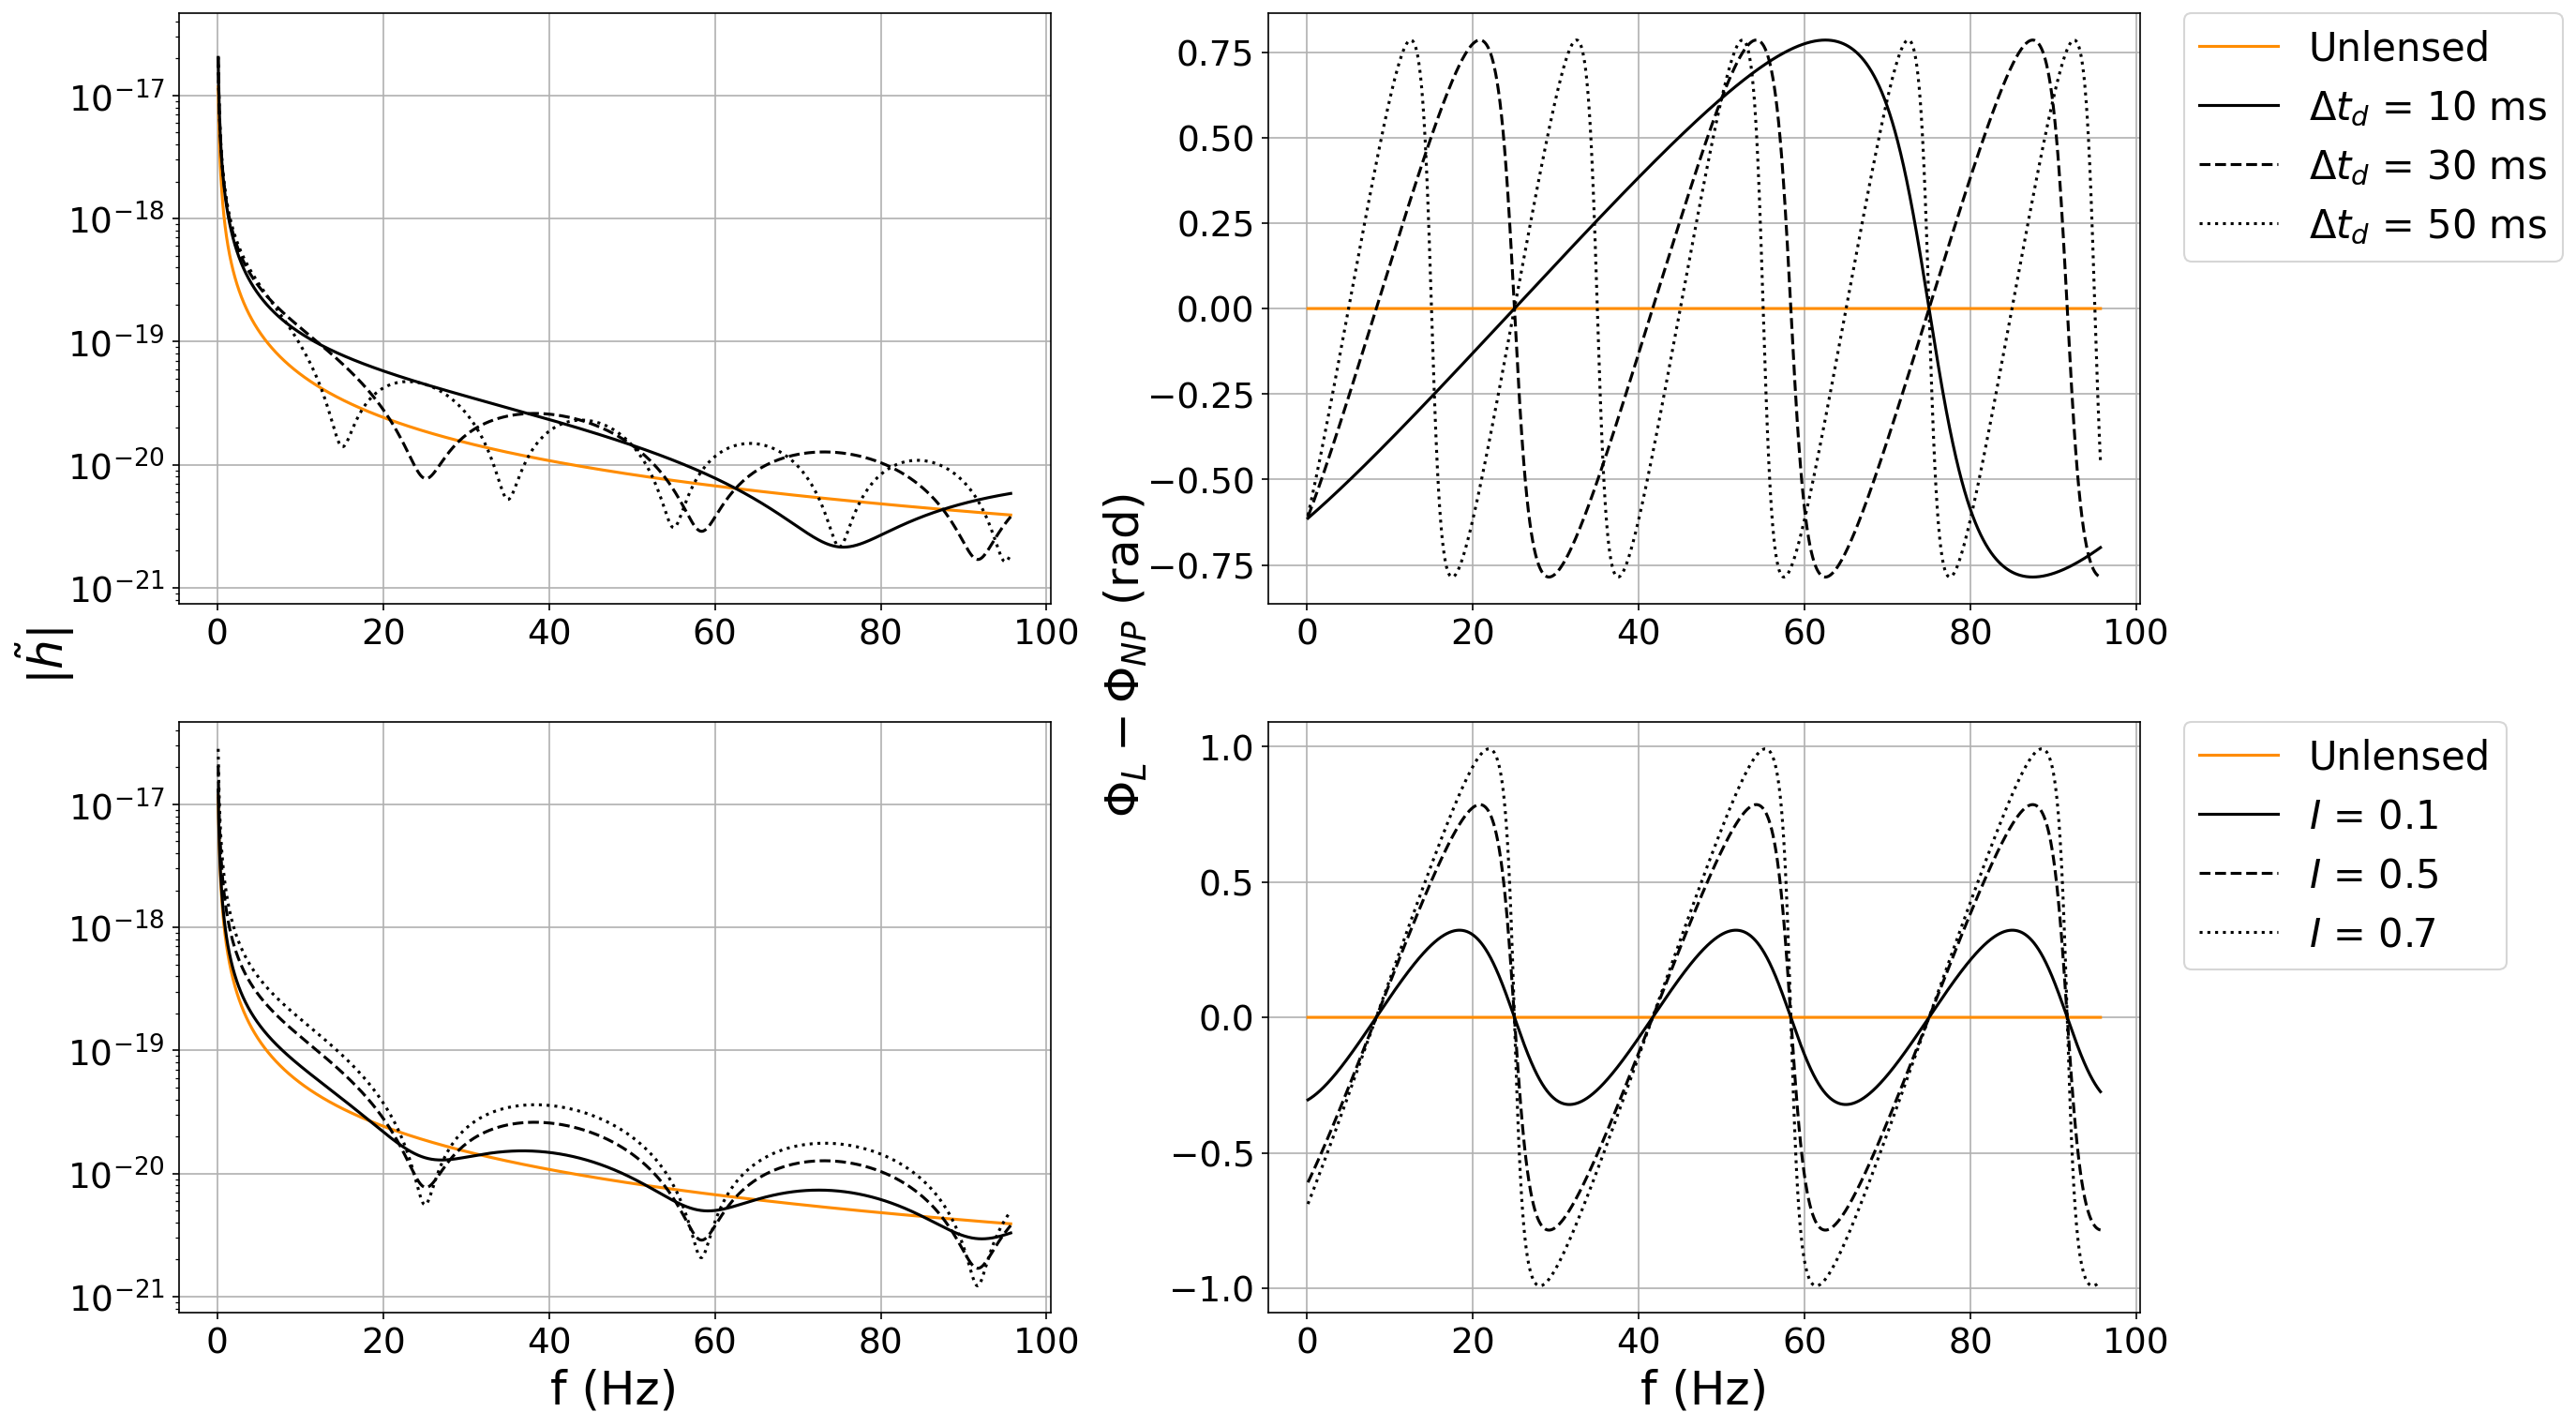

In [10]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=0.1,
    npoints=10000,
    z=0.0001,
    save_path="../figures/waveforms_lensed.pdf",
)

Applied redshift z=5 (mcz treated as source-frame)


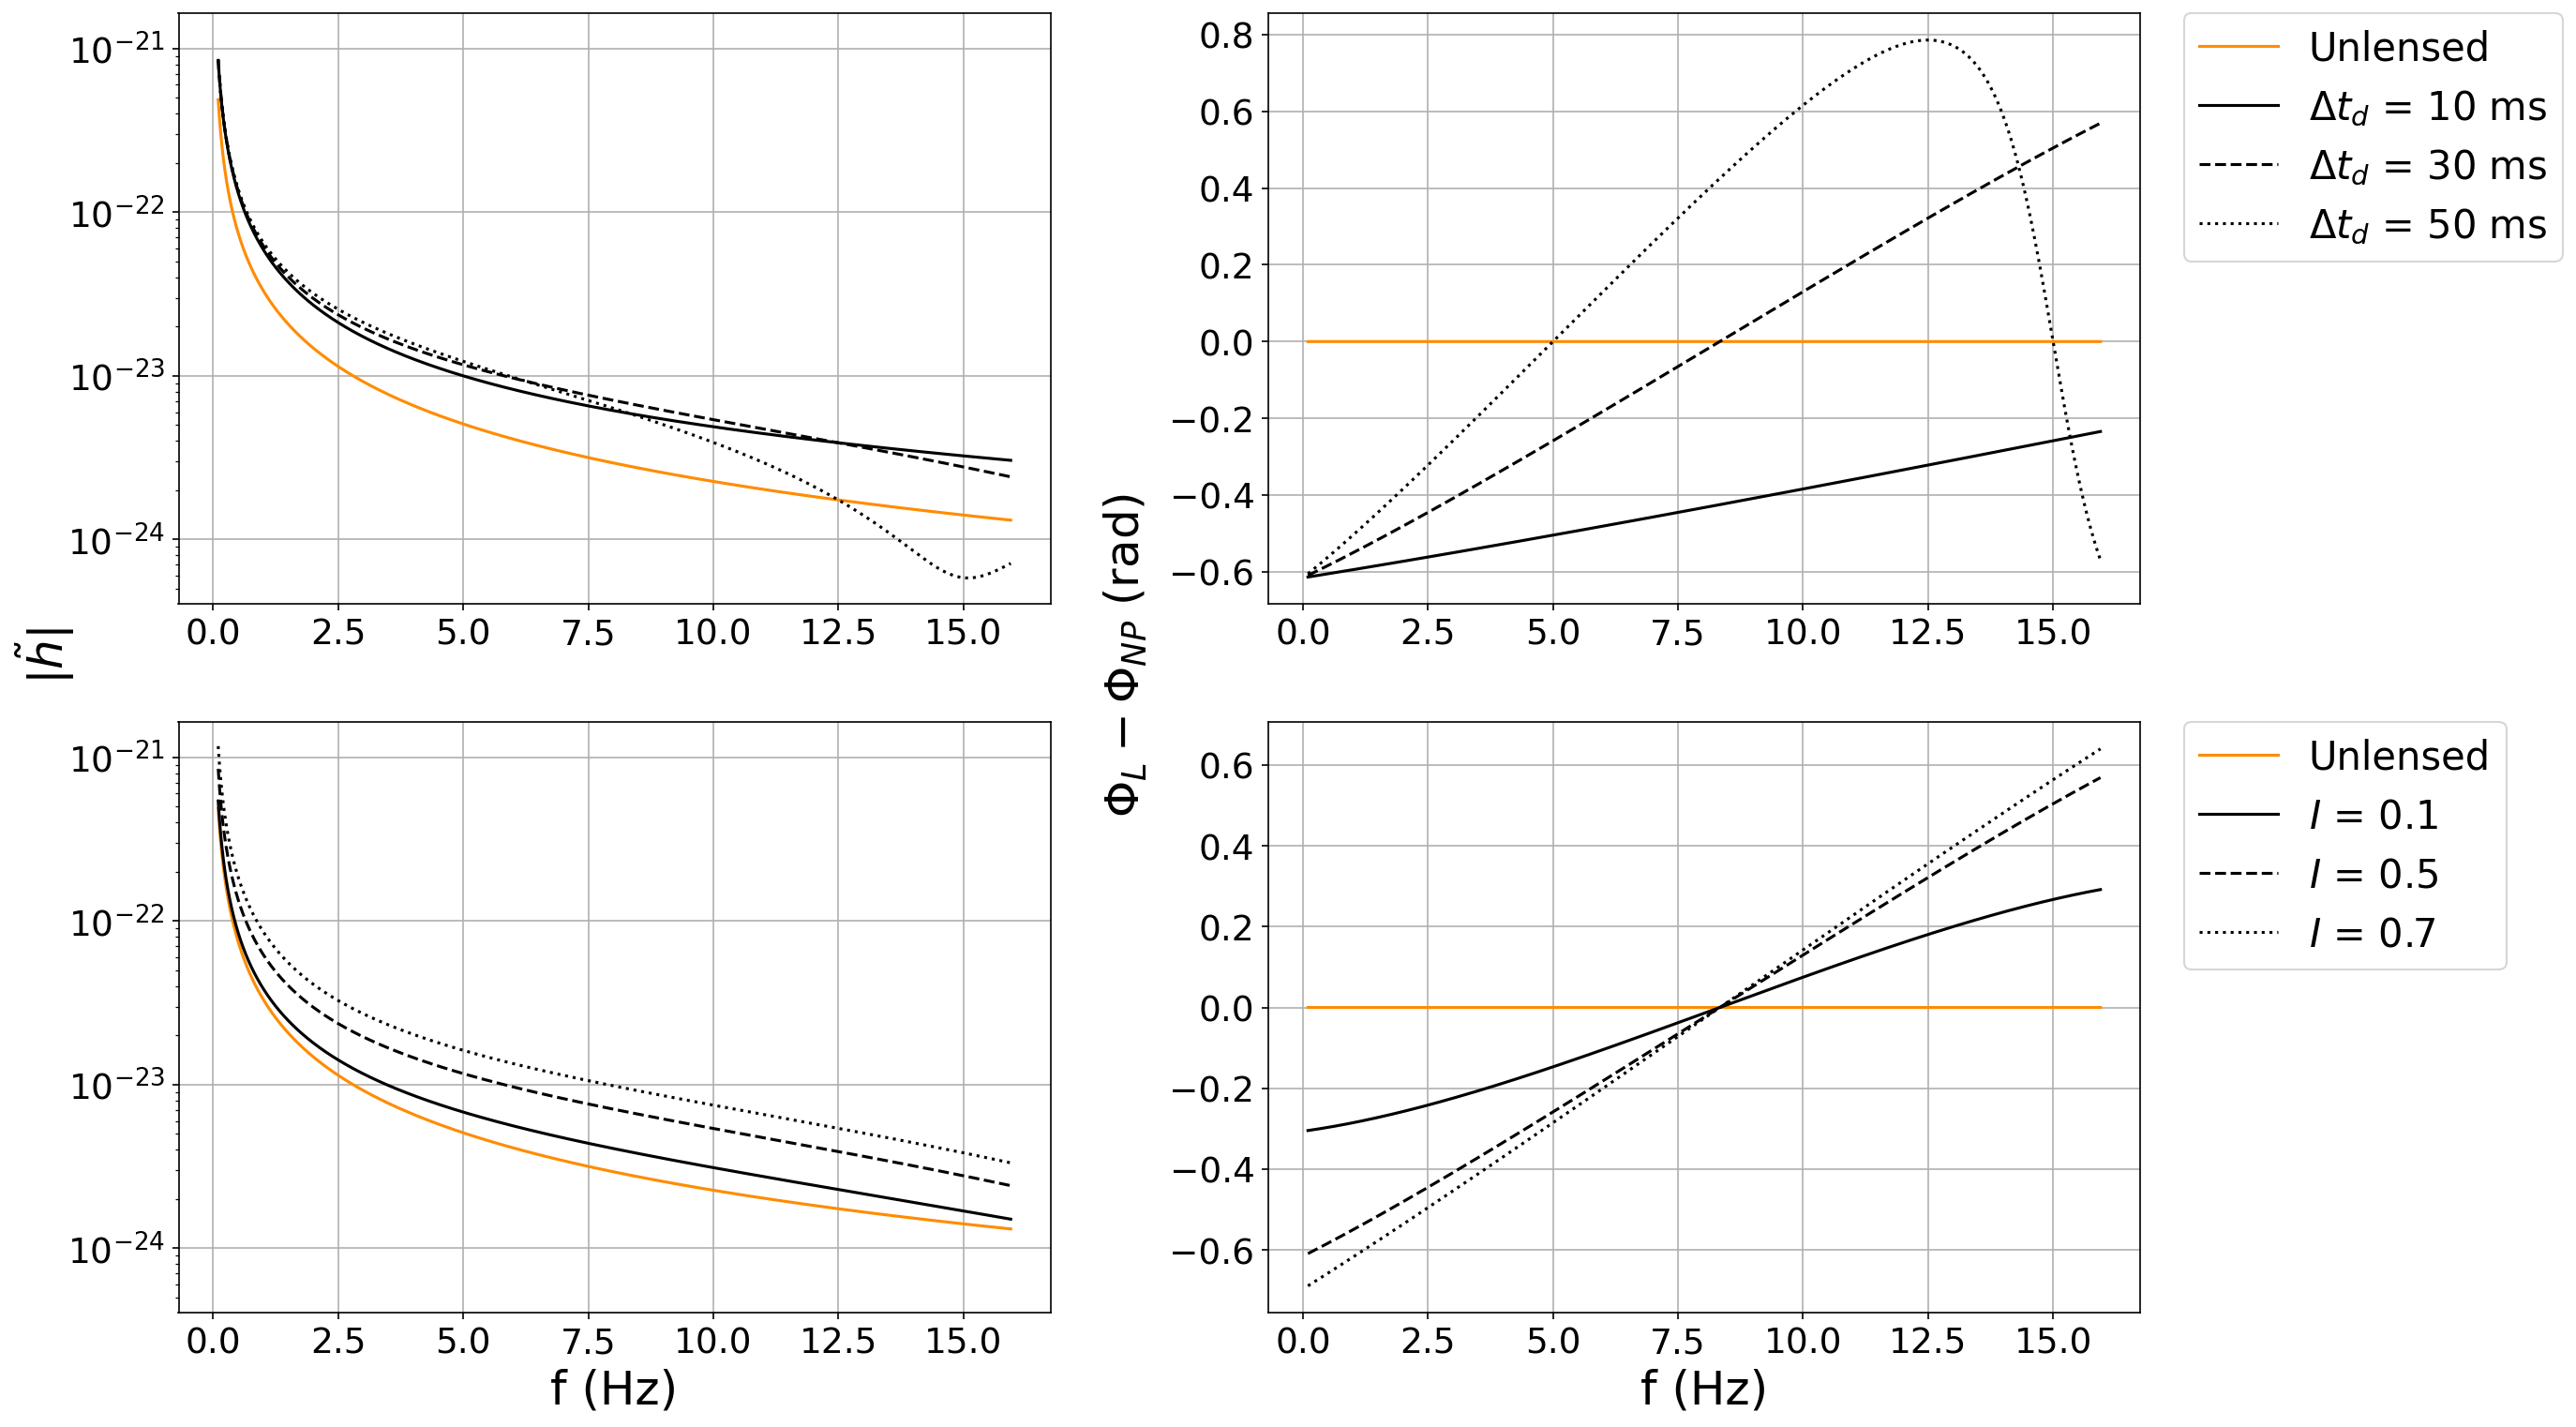

In [14]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=0.1,
    npoints=10000,
    z=5,
    save_path="../figures/waveforms_lensed.pdf",
)

Applied redshift z=0.0001 (mcz treated as source-frame)


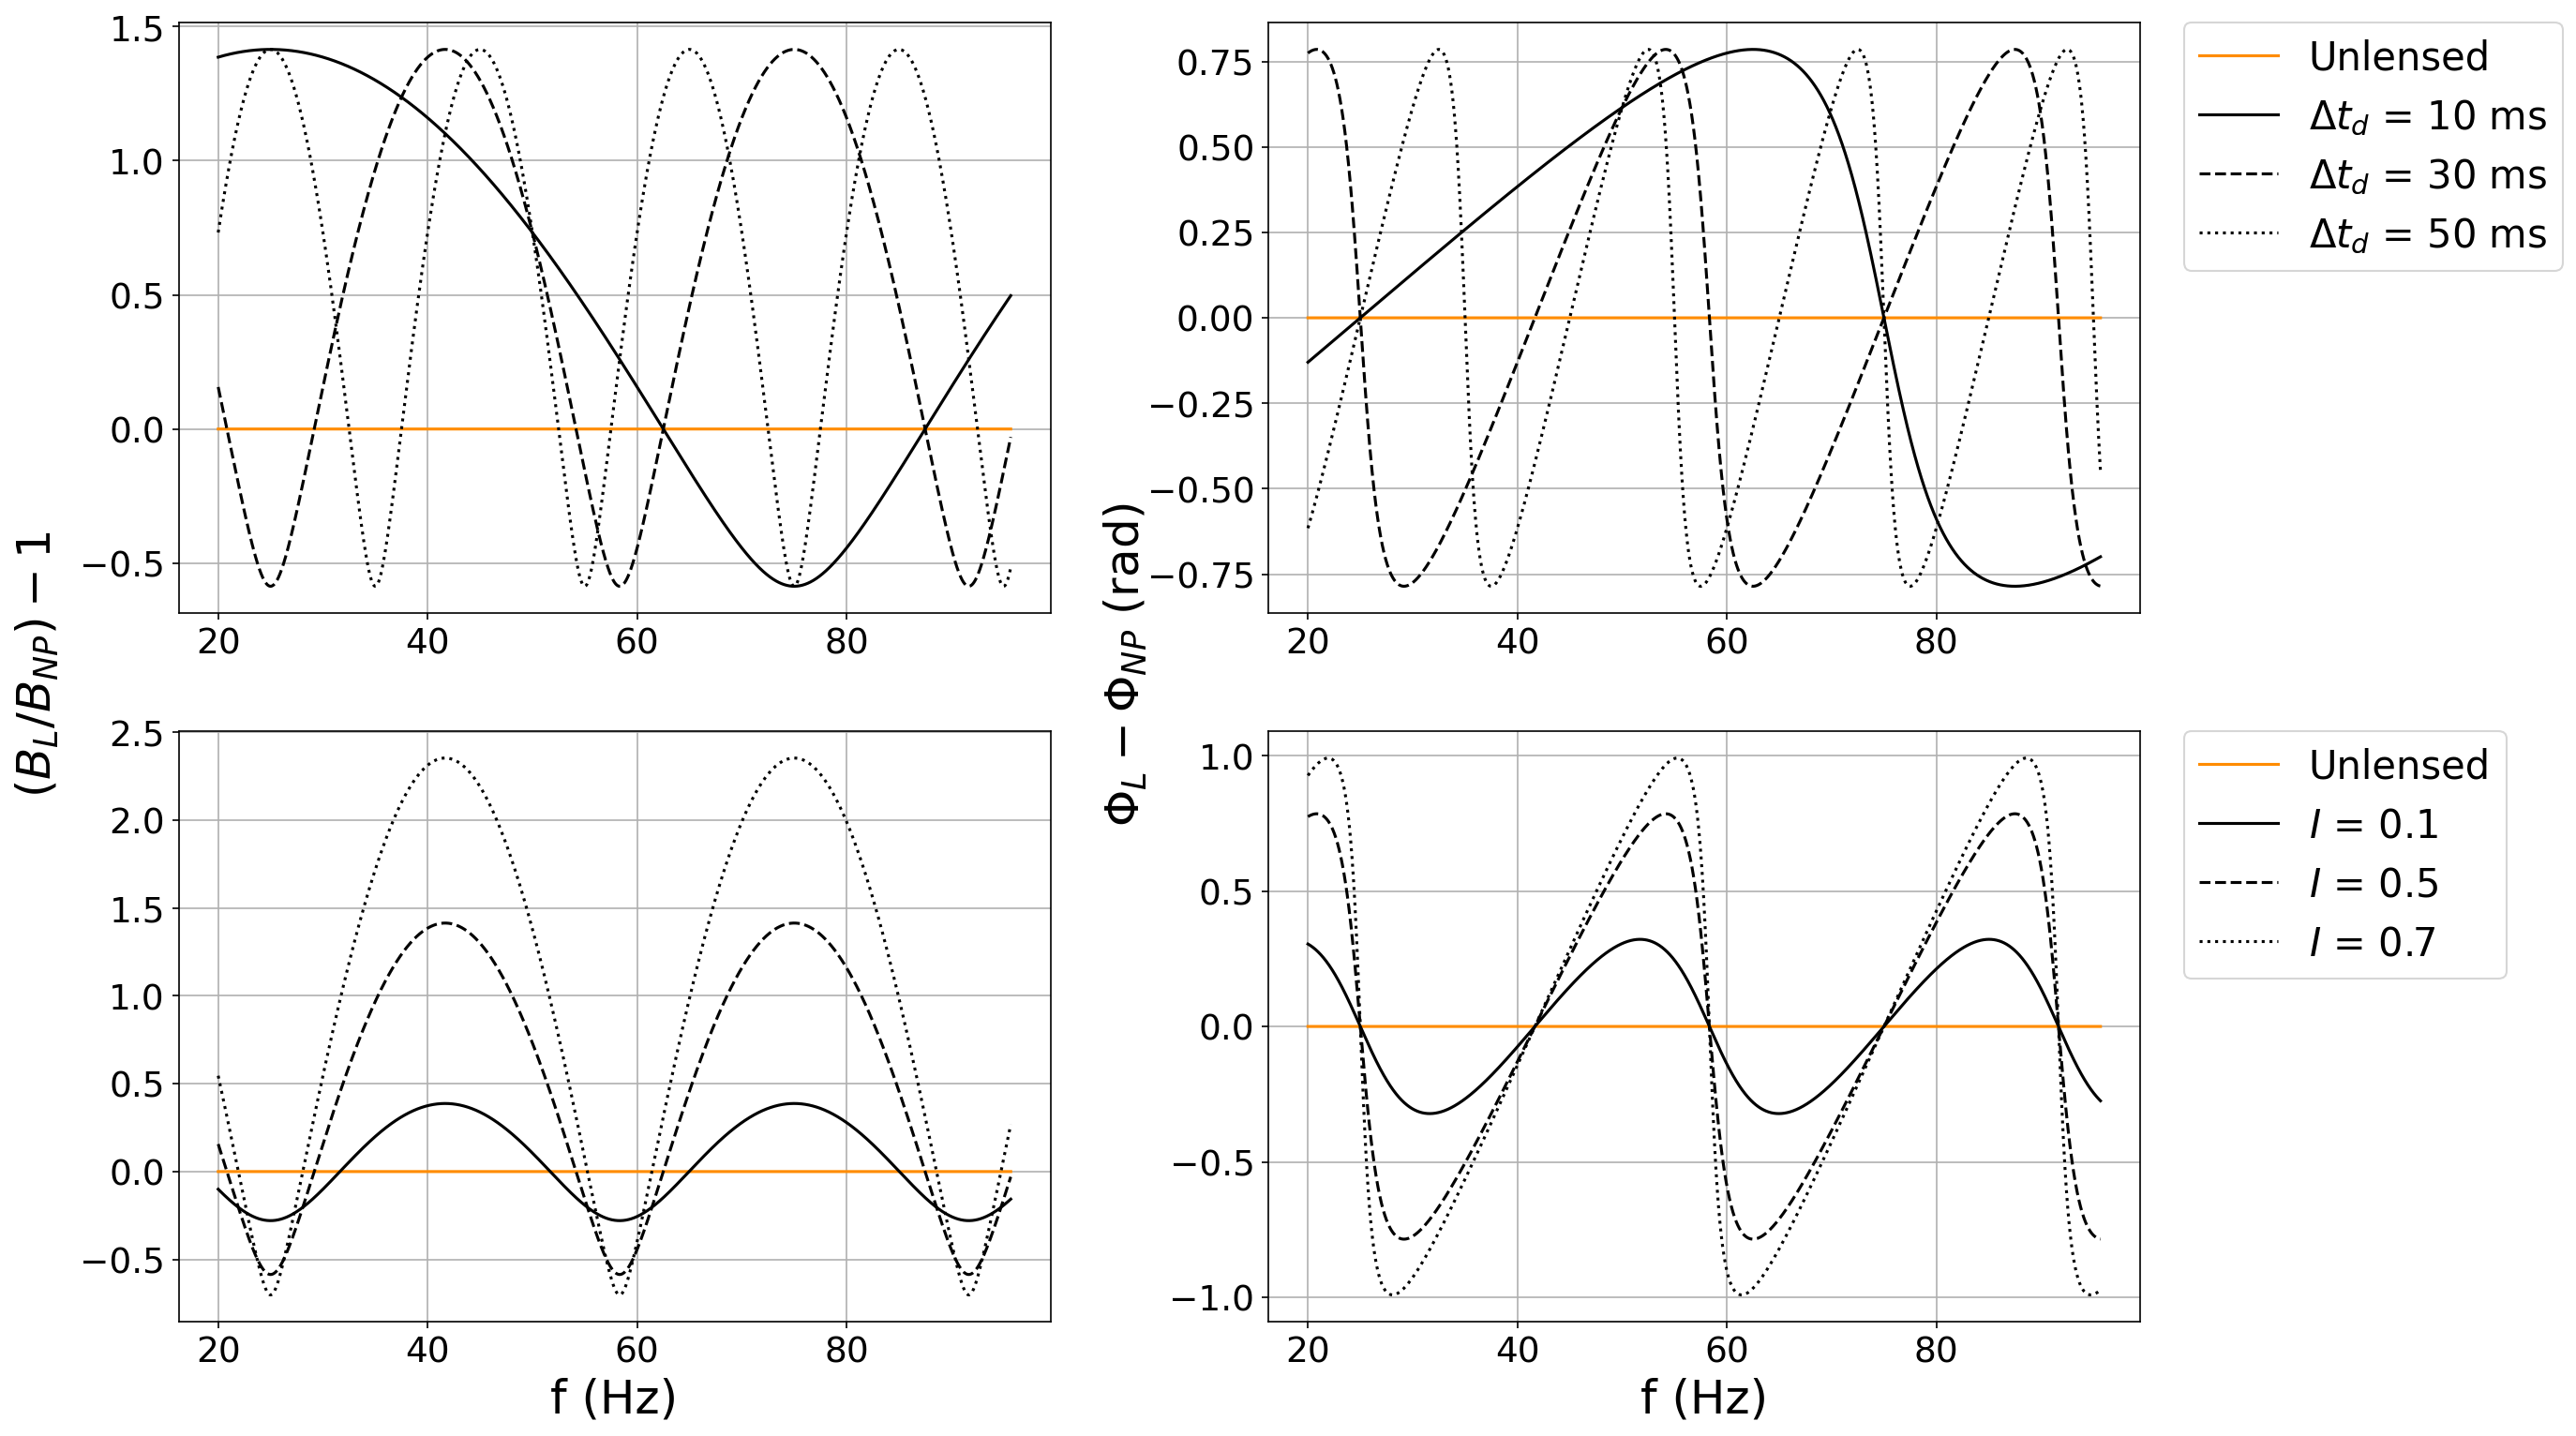

In [39]:
lens_params_1["mcz"] = 20 * SOLMASS2SEC

td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    z=0.0001,
    save_path="../figures/waveforms_lensed.pdf",
)

Applied redshift z=1 (mcz treated as source-frame)


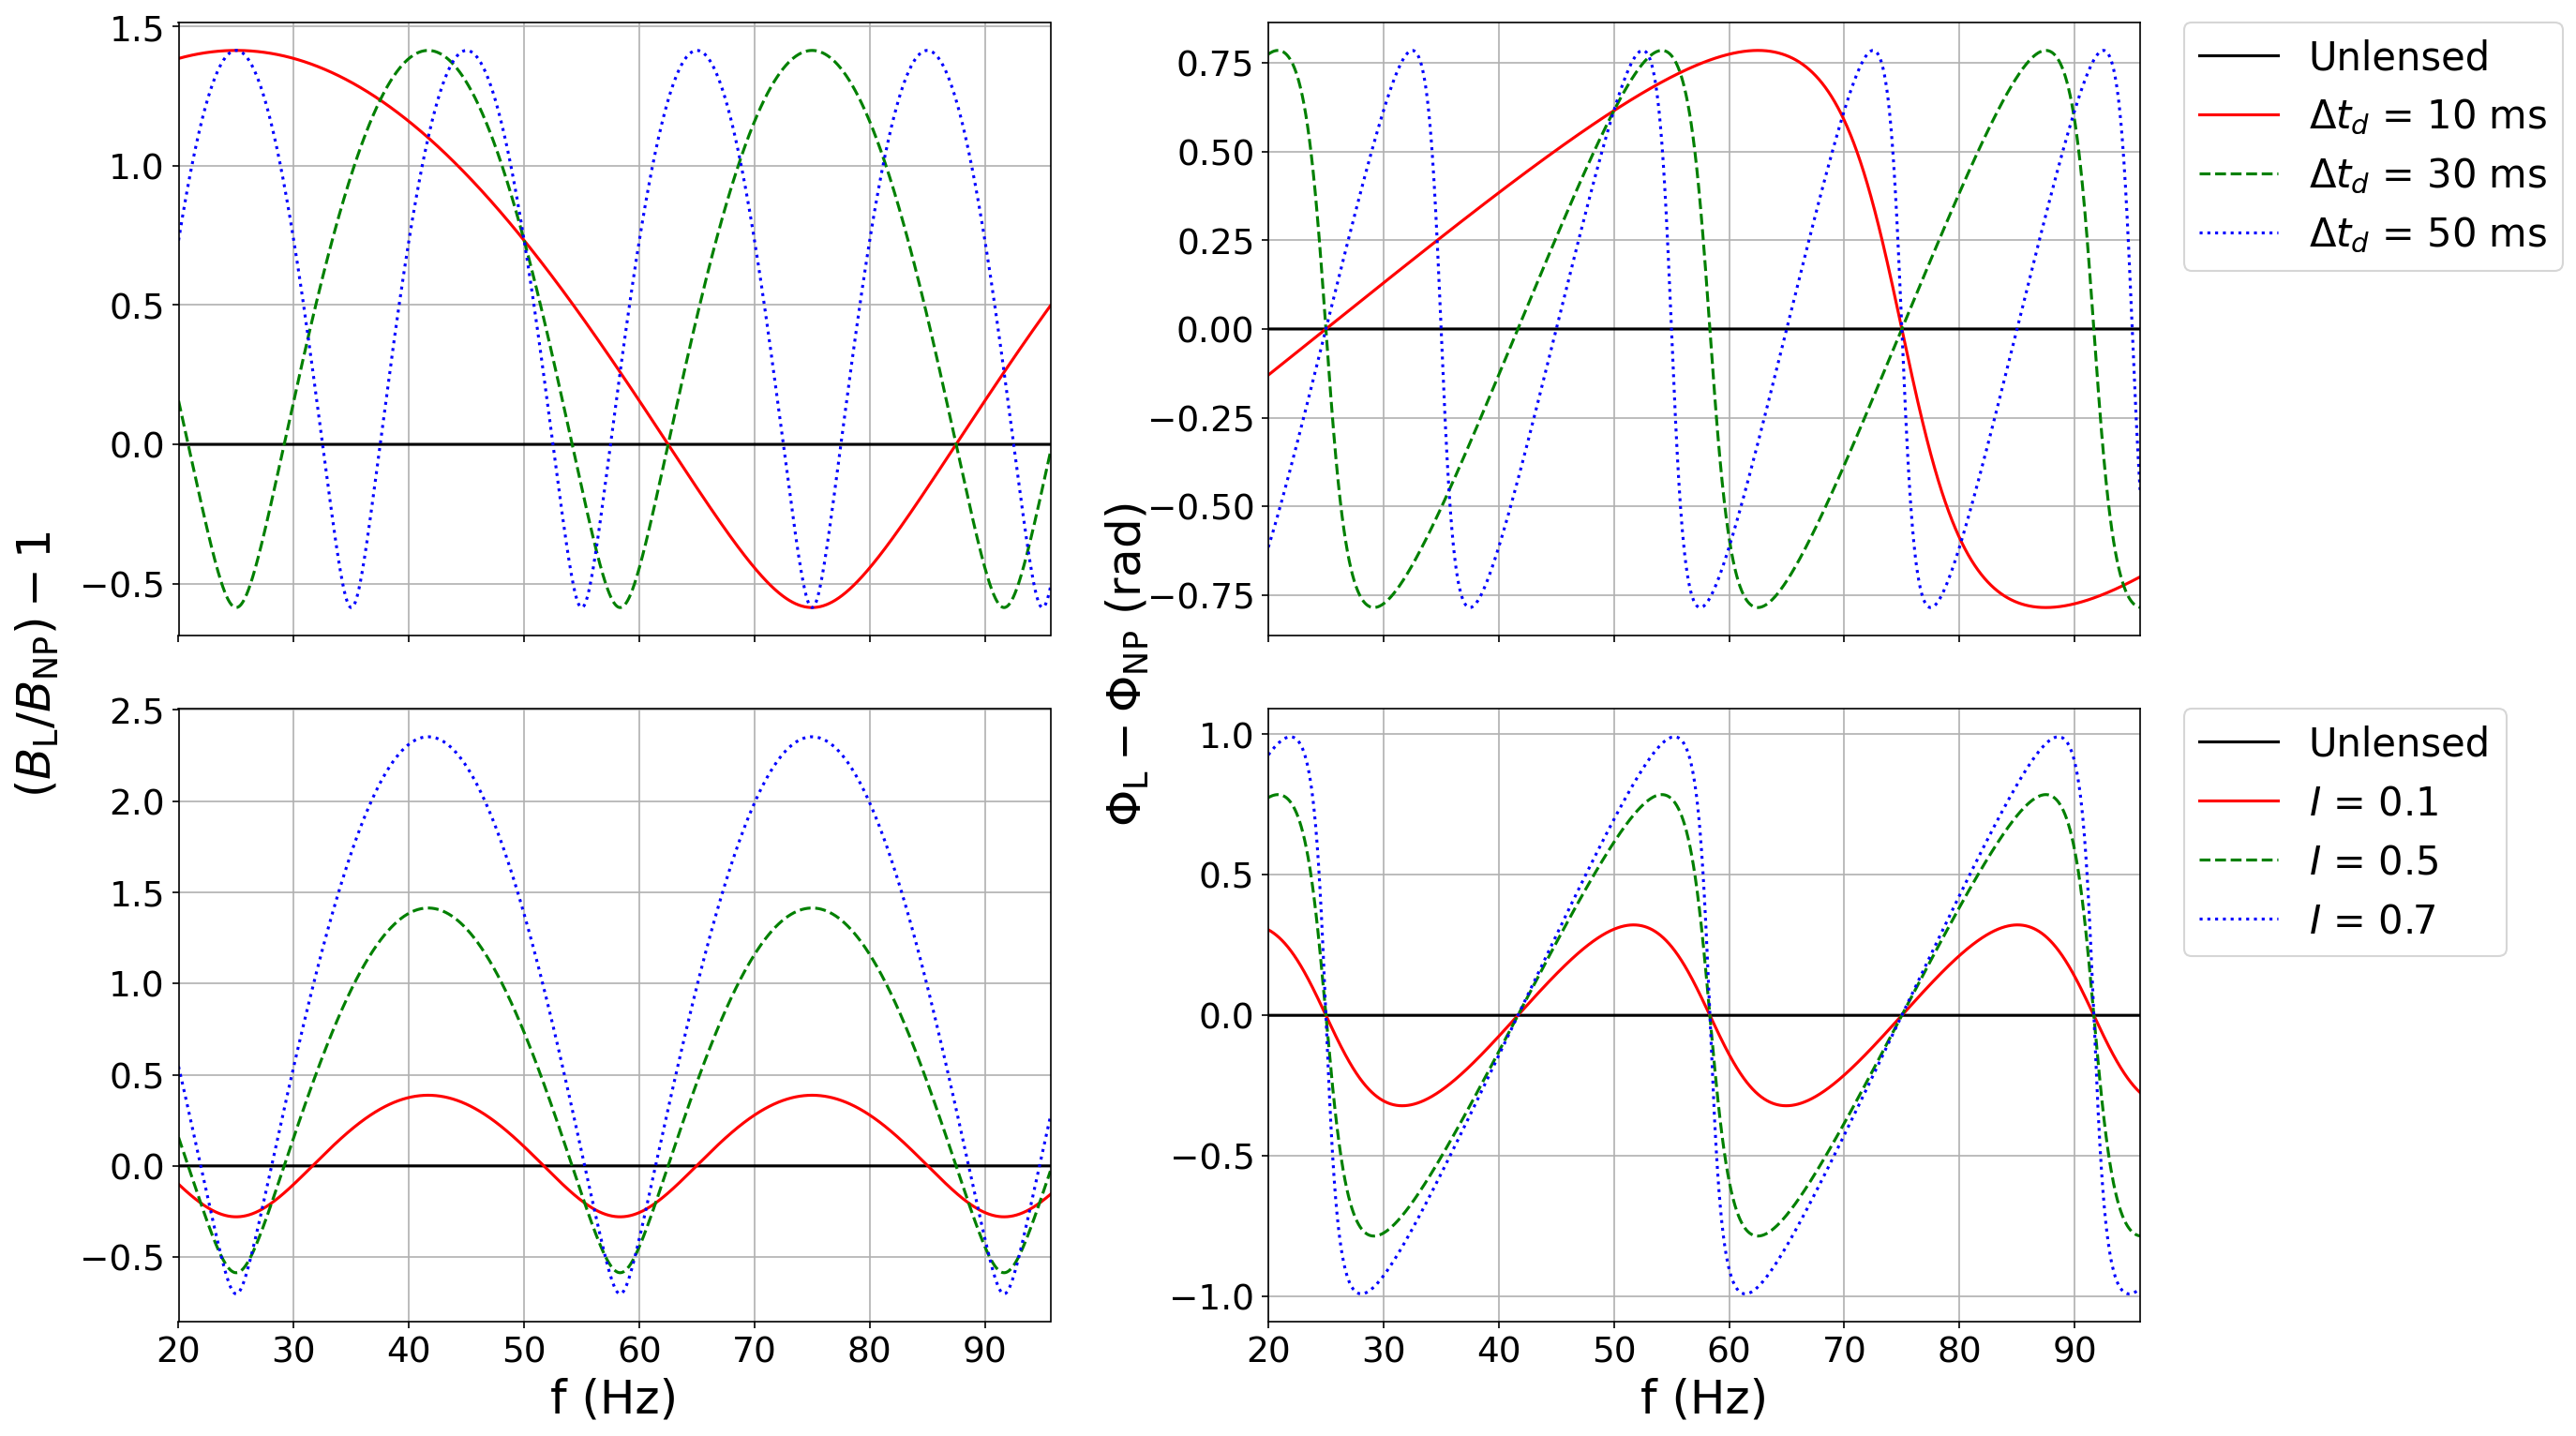

In [4]:
lens_params_1["mcz"] = 10 * SOLMASS2SEC


td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    line_colors=linecolors,
    baseline_color="#000000",
    f_min=20,
    npoints=10000,
    z=1,
    save_path="../figures/waveforms/waveforms_lensed.pdf",
)

# precessing

## random

Applied redshift z=0.0001 (mcz treated as source-frame)
system 3 in Taman's paper


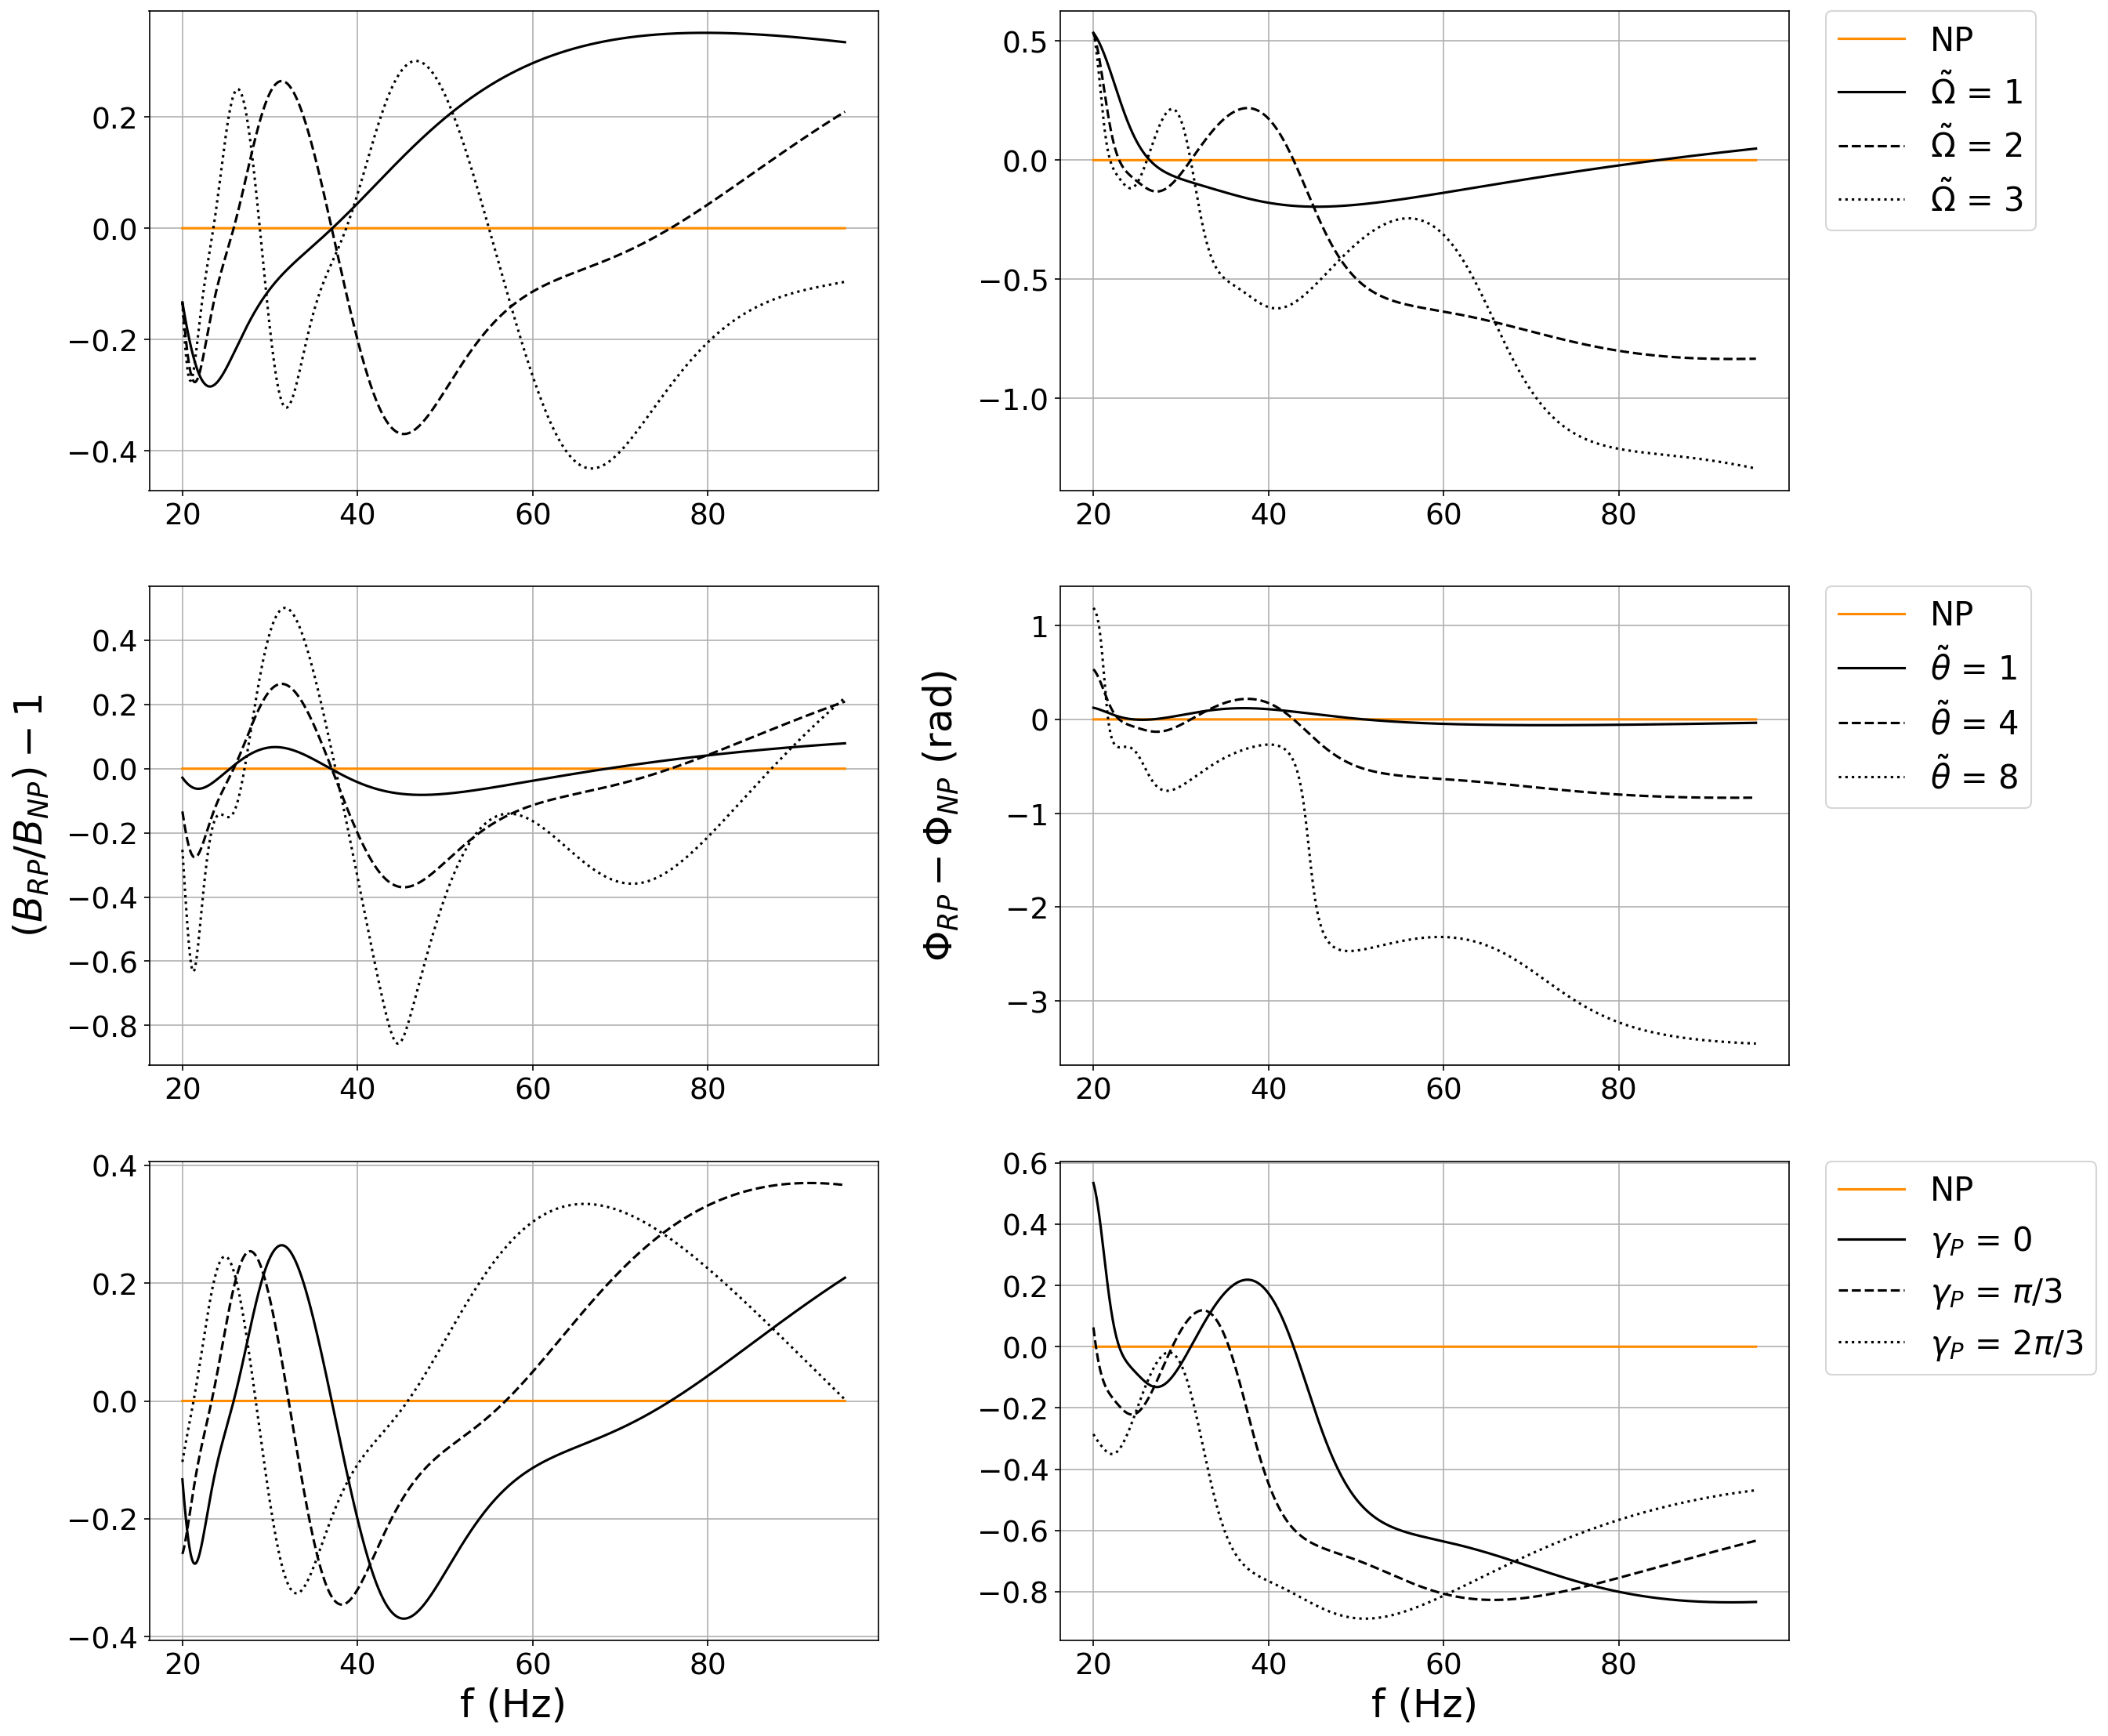

In [17]:
# Precessing (random): abs amplitude + phase
RP_params_1, NP_params_1 = set_orientation(
    loc_params["Taman"]["random"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    delta_f=0.05,
    z=0.0001,
)
print("system 3 in Taman's paper")

## edge-on

Applied redshift z=0.0001 (mcz treated as source-frame)
system 2 in Taman's paper


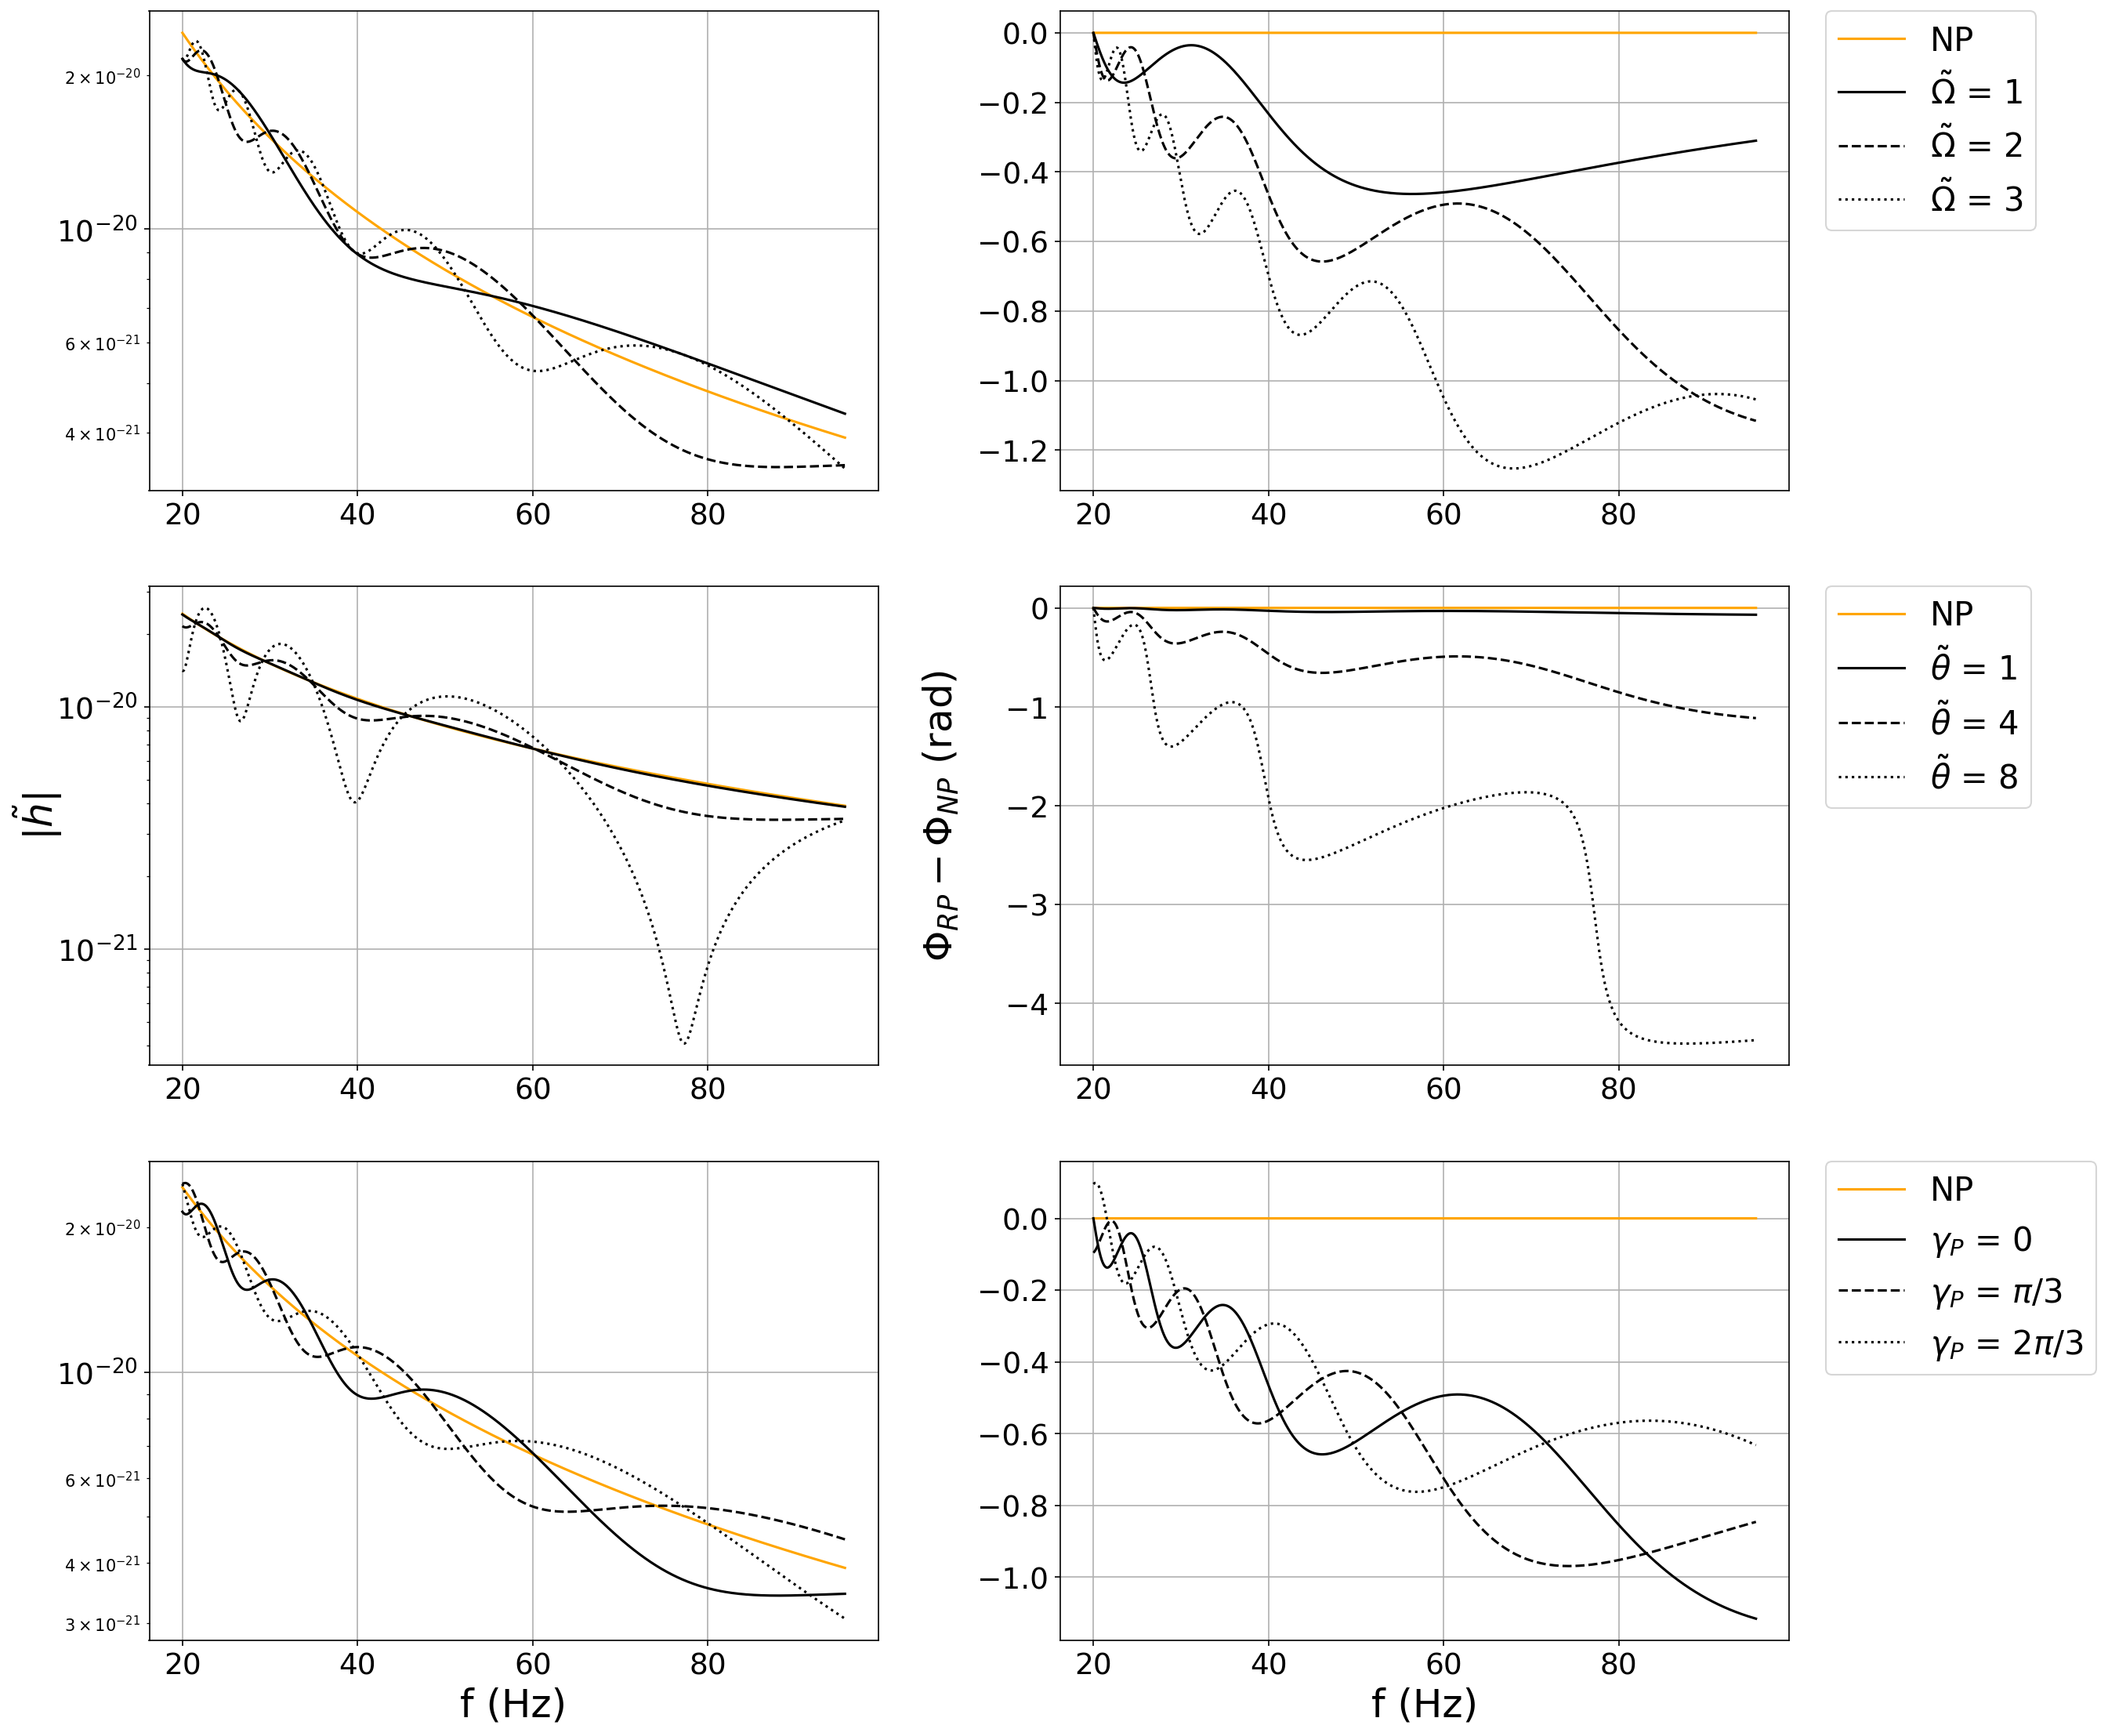

In [18]:
# Precessing (edge-on): abs amplitude + phase
RP_params_1, NP_params_1 = set_orientation(
    loc_params["Taman"]["edgeon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=0.0001,
)
print("system 2 in Taman's paper")

Applied redshift z=0.1 (mcz treated as source-frame)
system 2 in Taman's paper


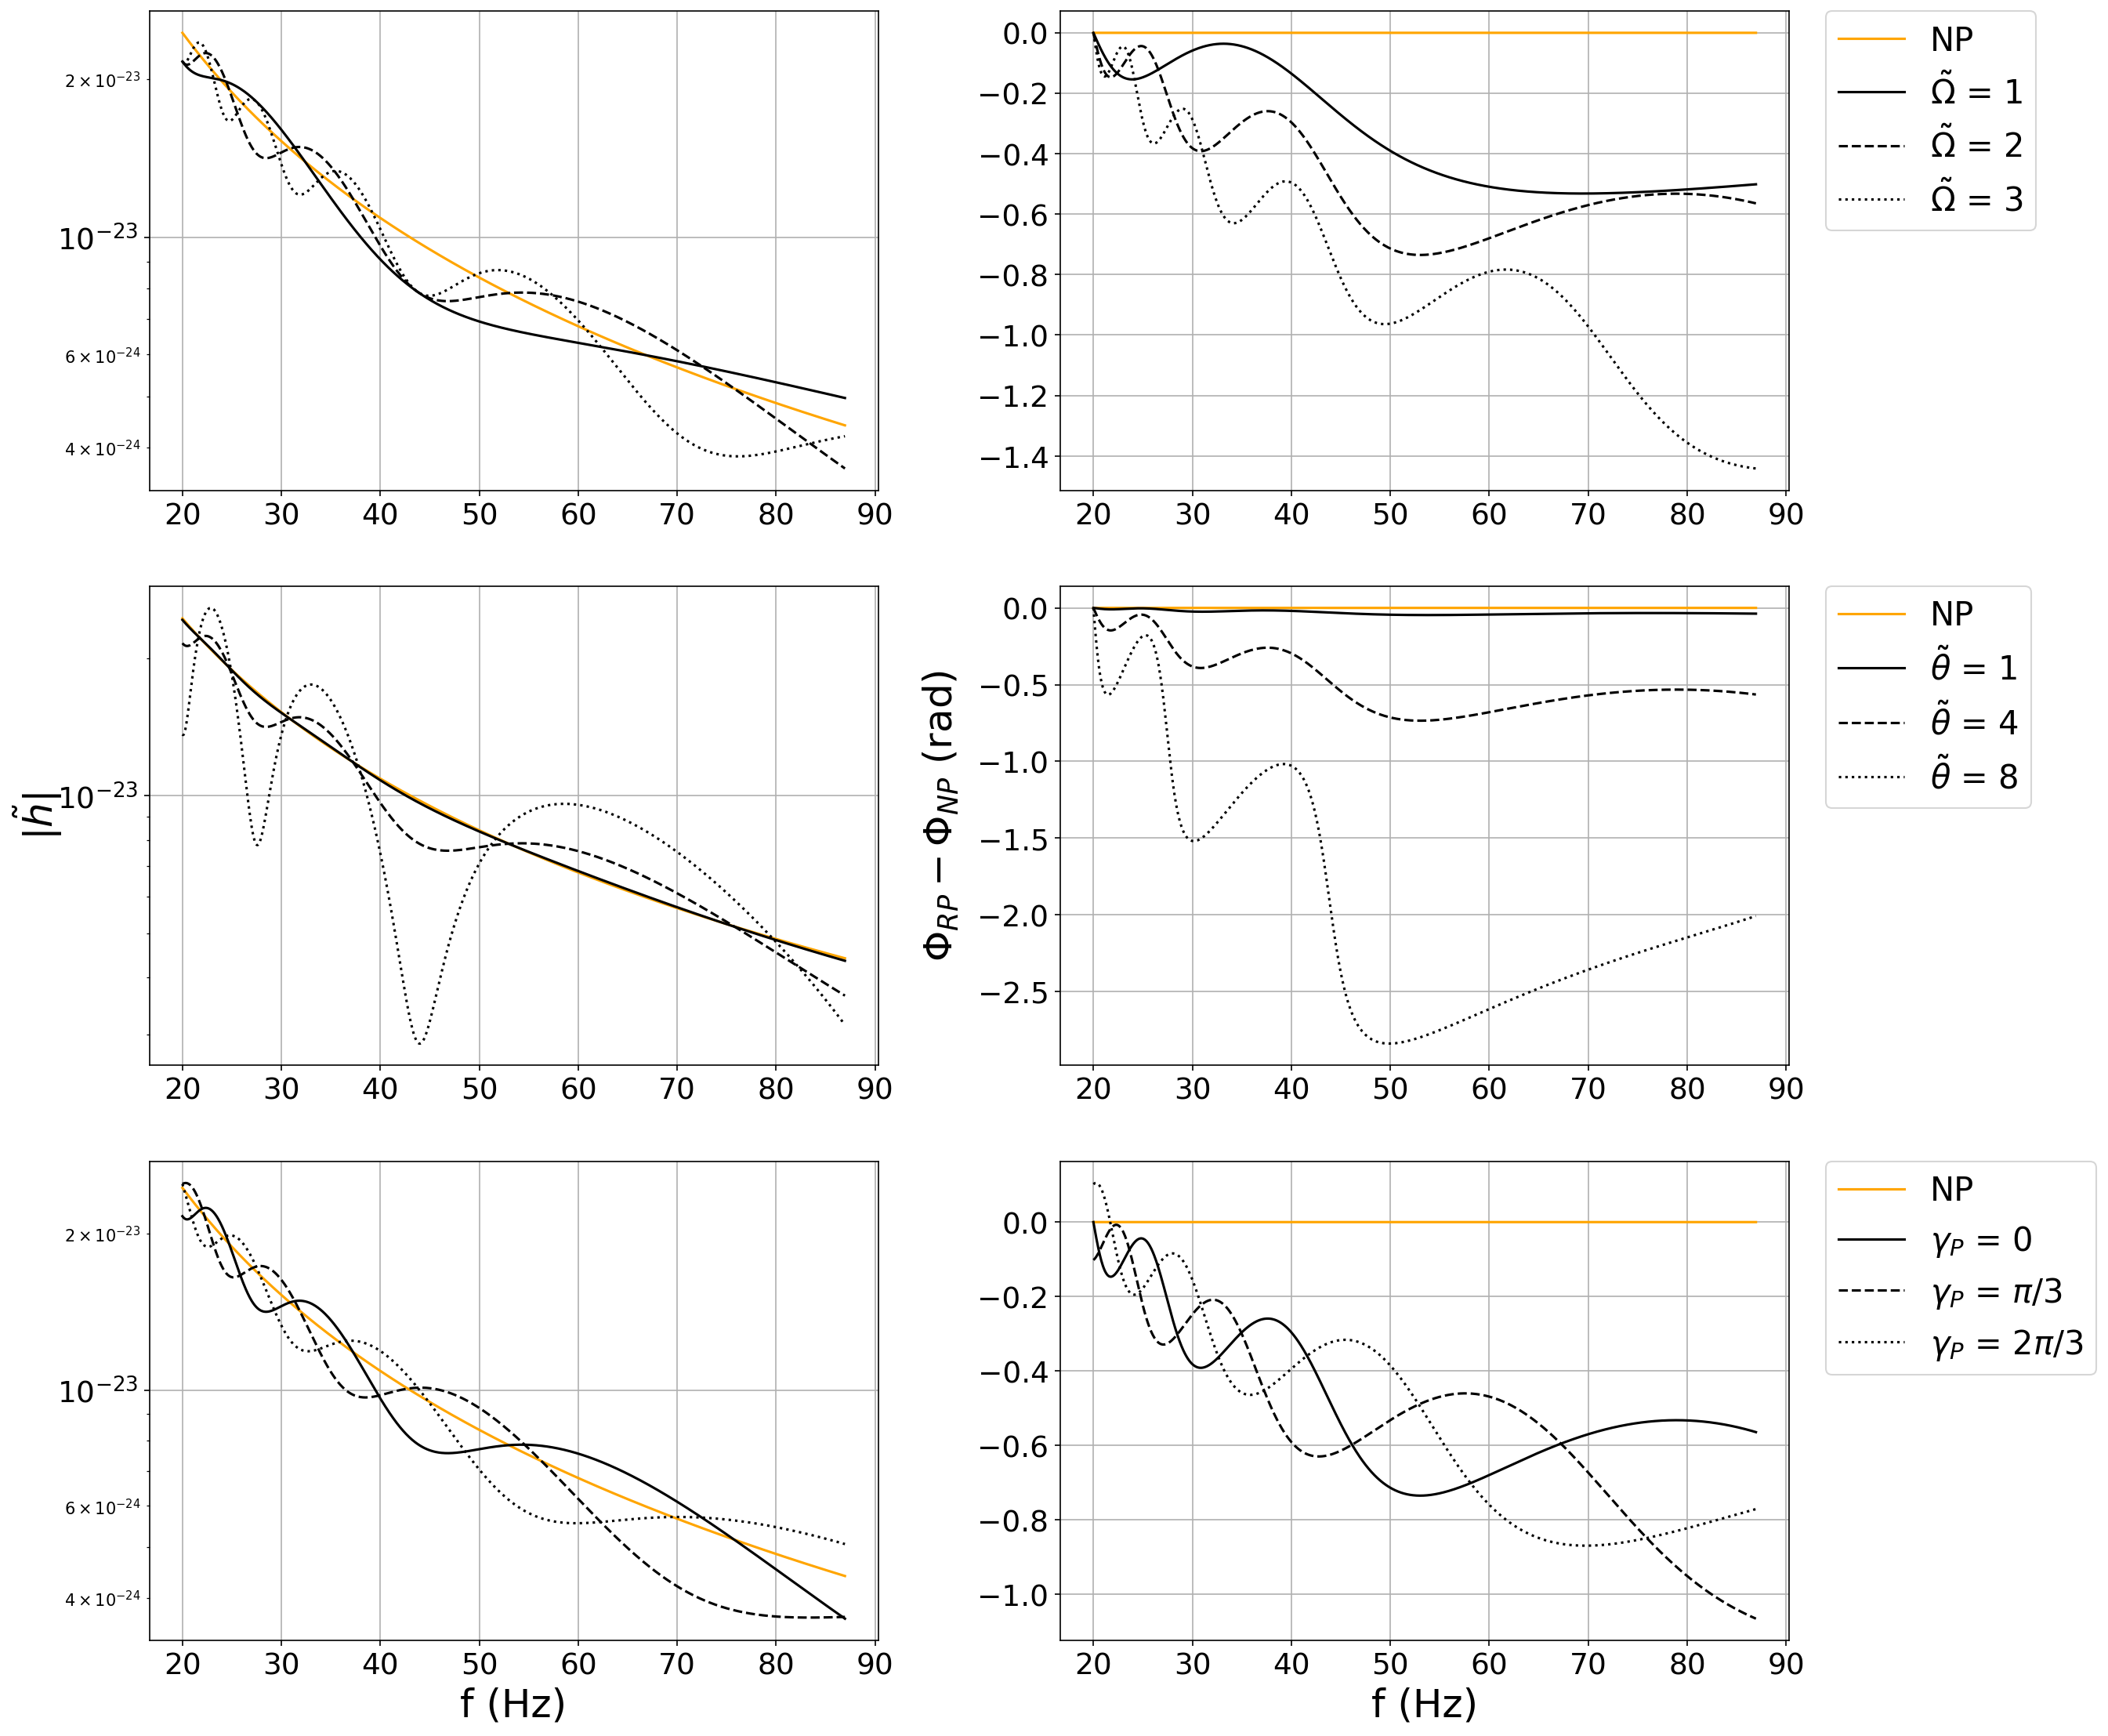

In [19]:
# Precessing (edge-on): abs amplitude + phase
RP_params_1, NP_params_1 = set_orientation(
    loc_params["Taman"]["edgeon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=0.1,
)
print("system 2 in Taman's paper")

Applied redshift z=0.0001 (mcz treated as source-frame)
system 2 in Taman's paper


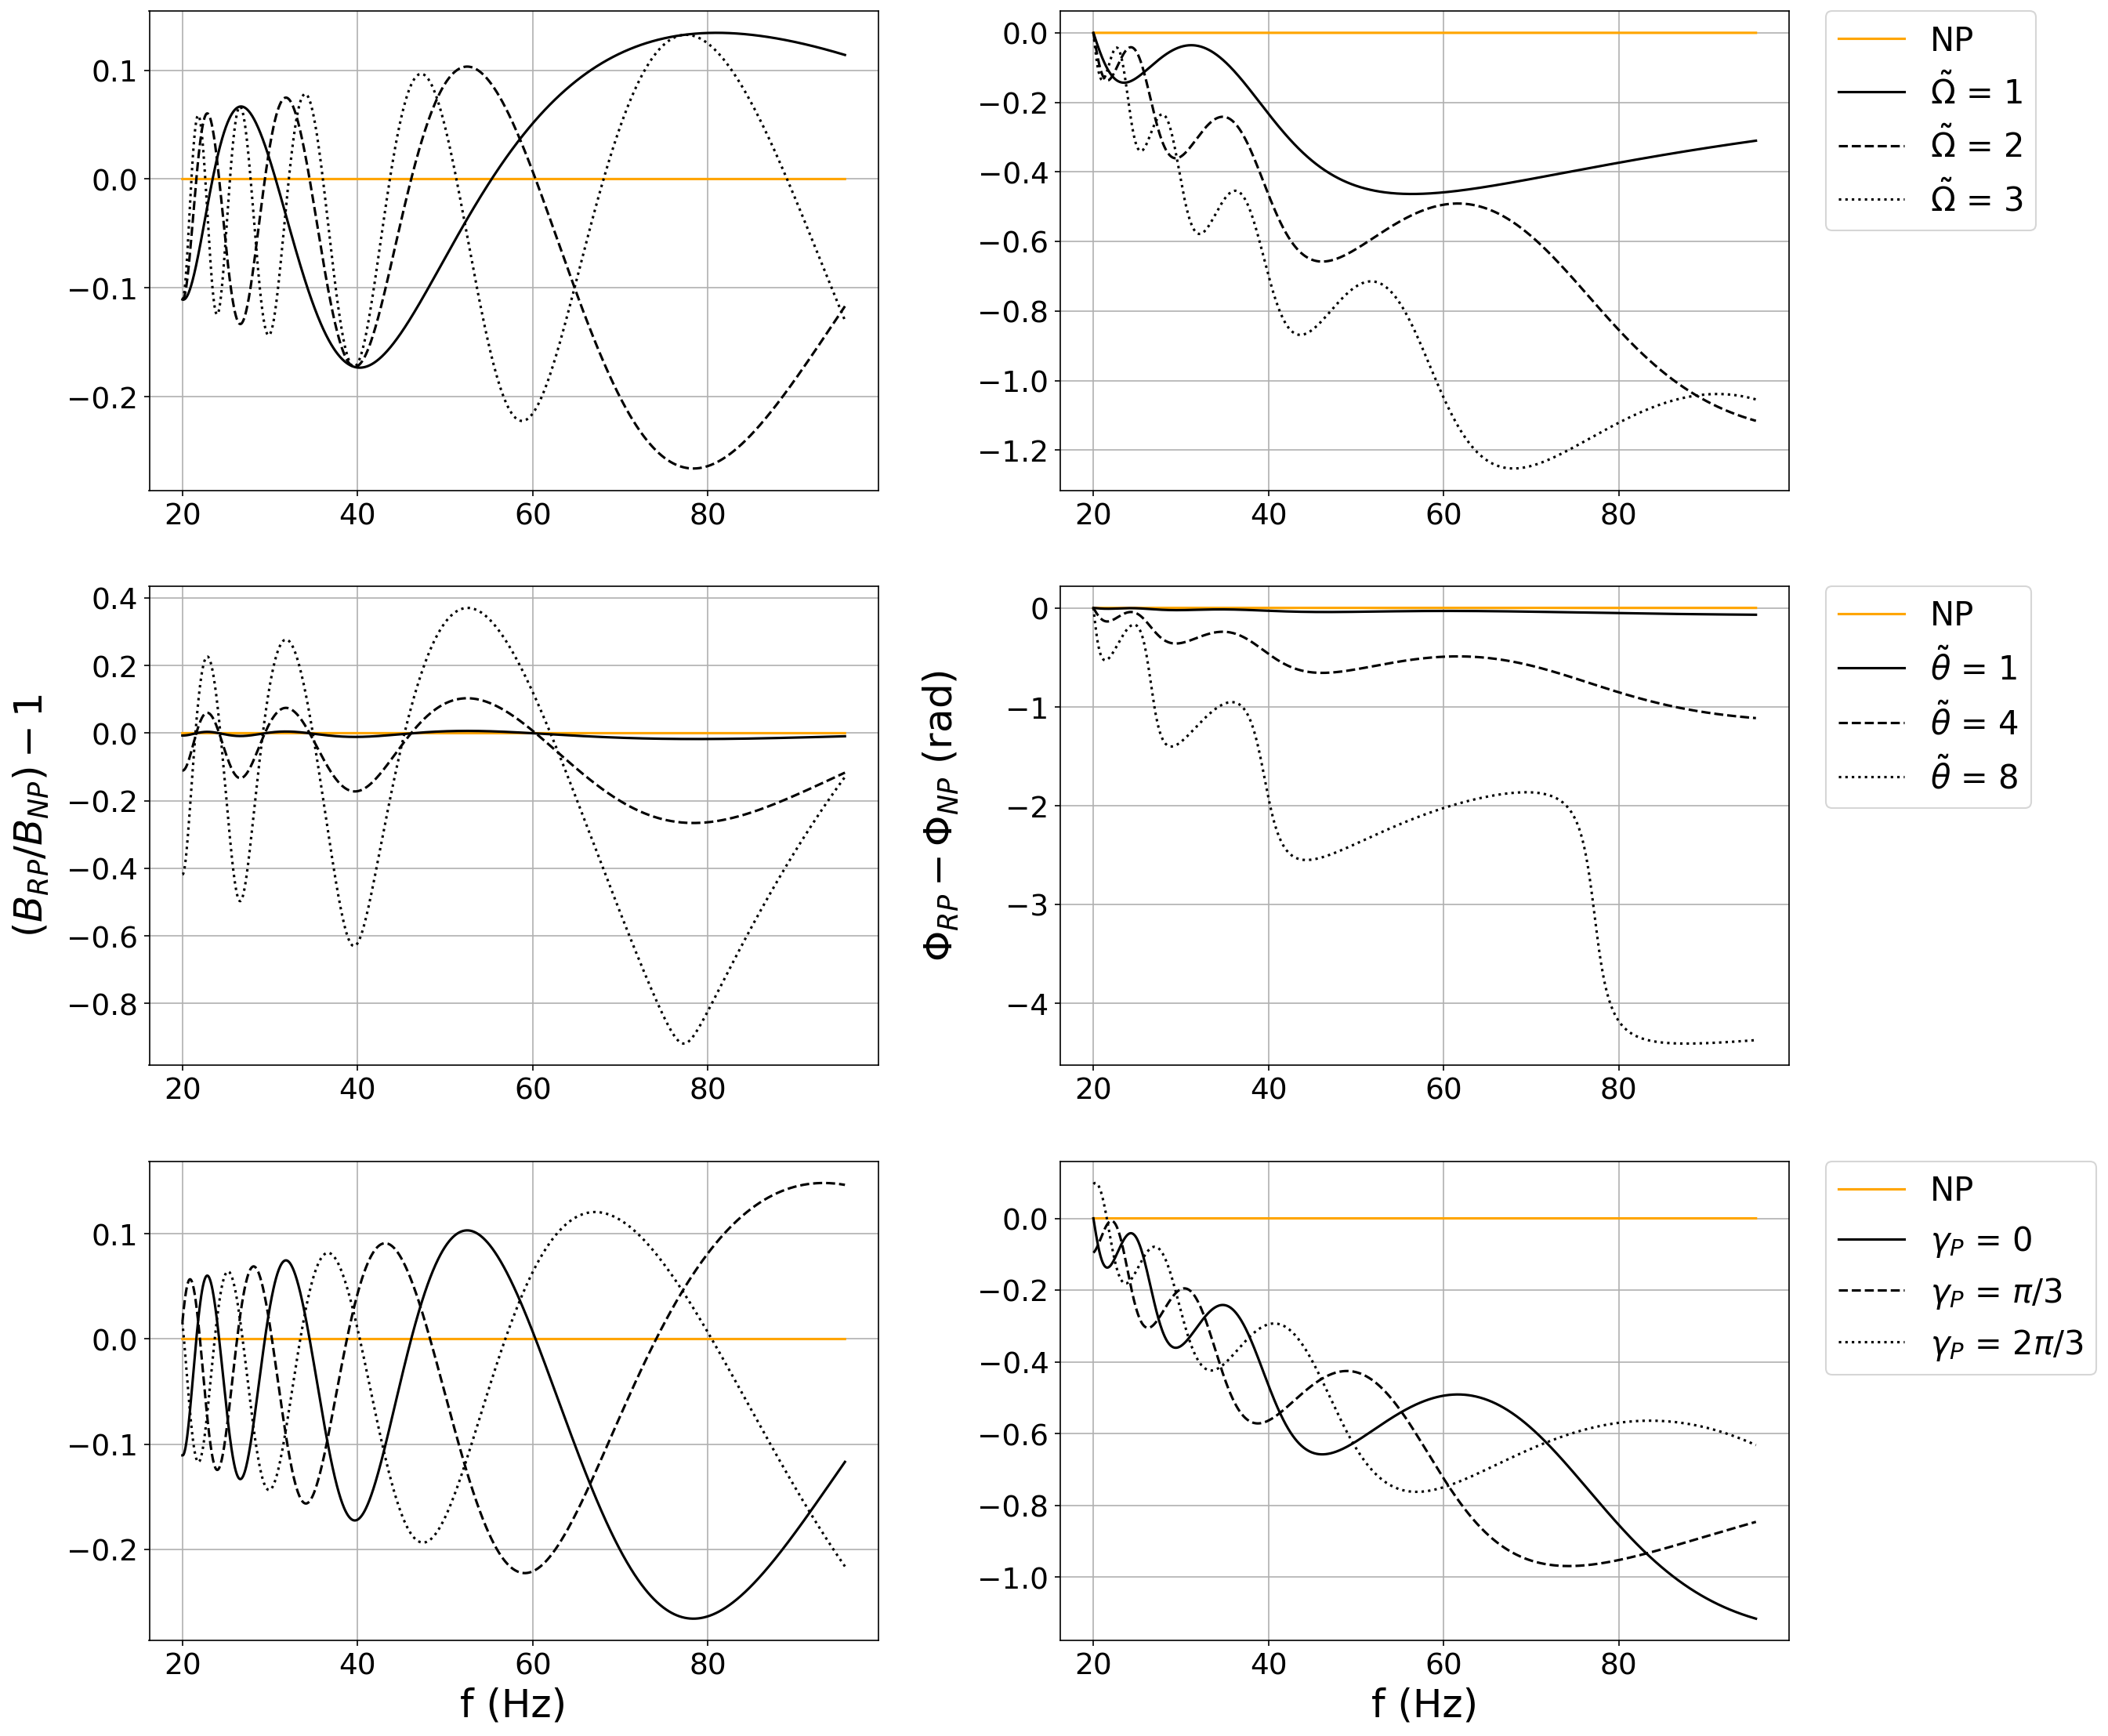

In [20]:
# Precessing (edge-on): amplitude ratio + phase
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=0.0001,
    save_path="../figures/waveforms_RP_sys2.pdf",
)
print("system 2 in Taman's paper")

Applied redshift z=1 (mcz treated as source-frame)
system 2 in Taman's paper


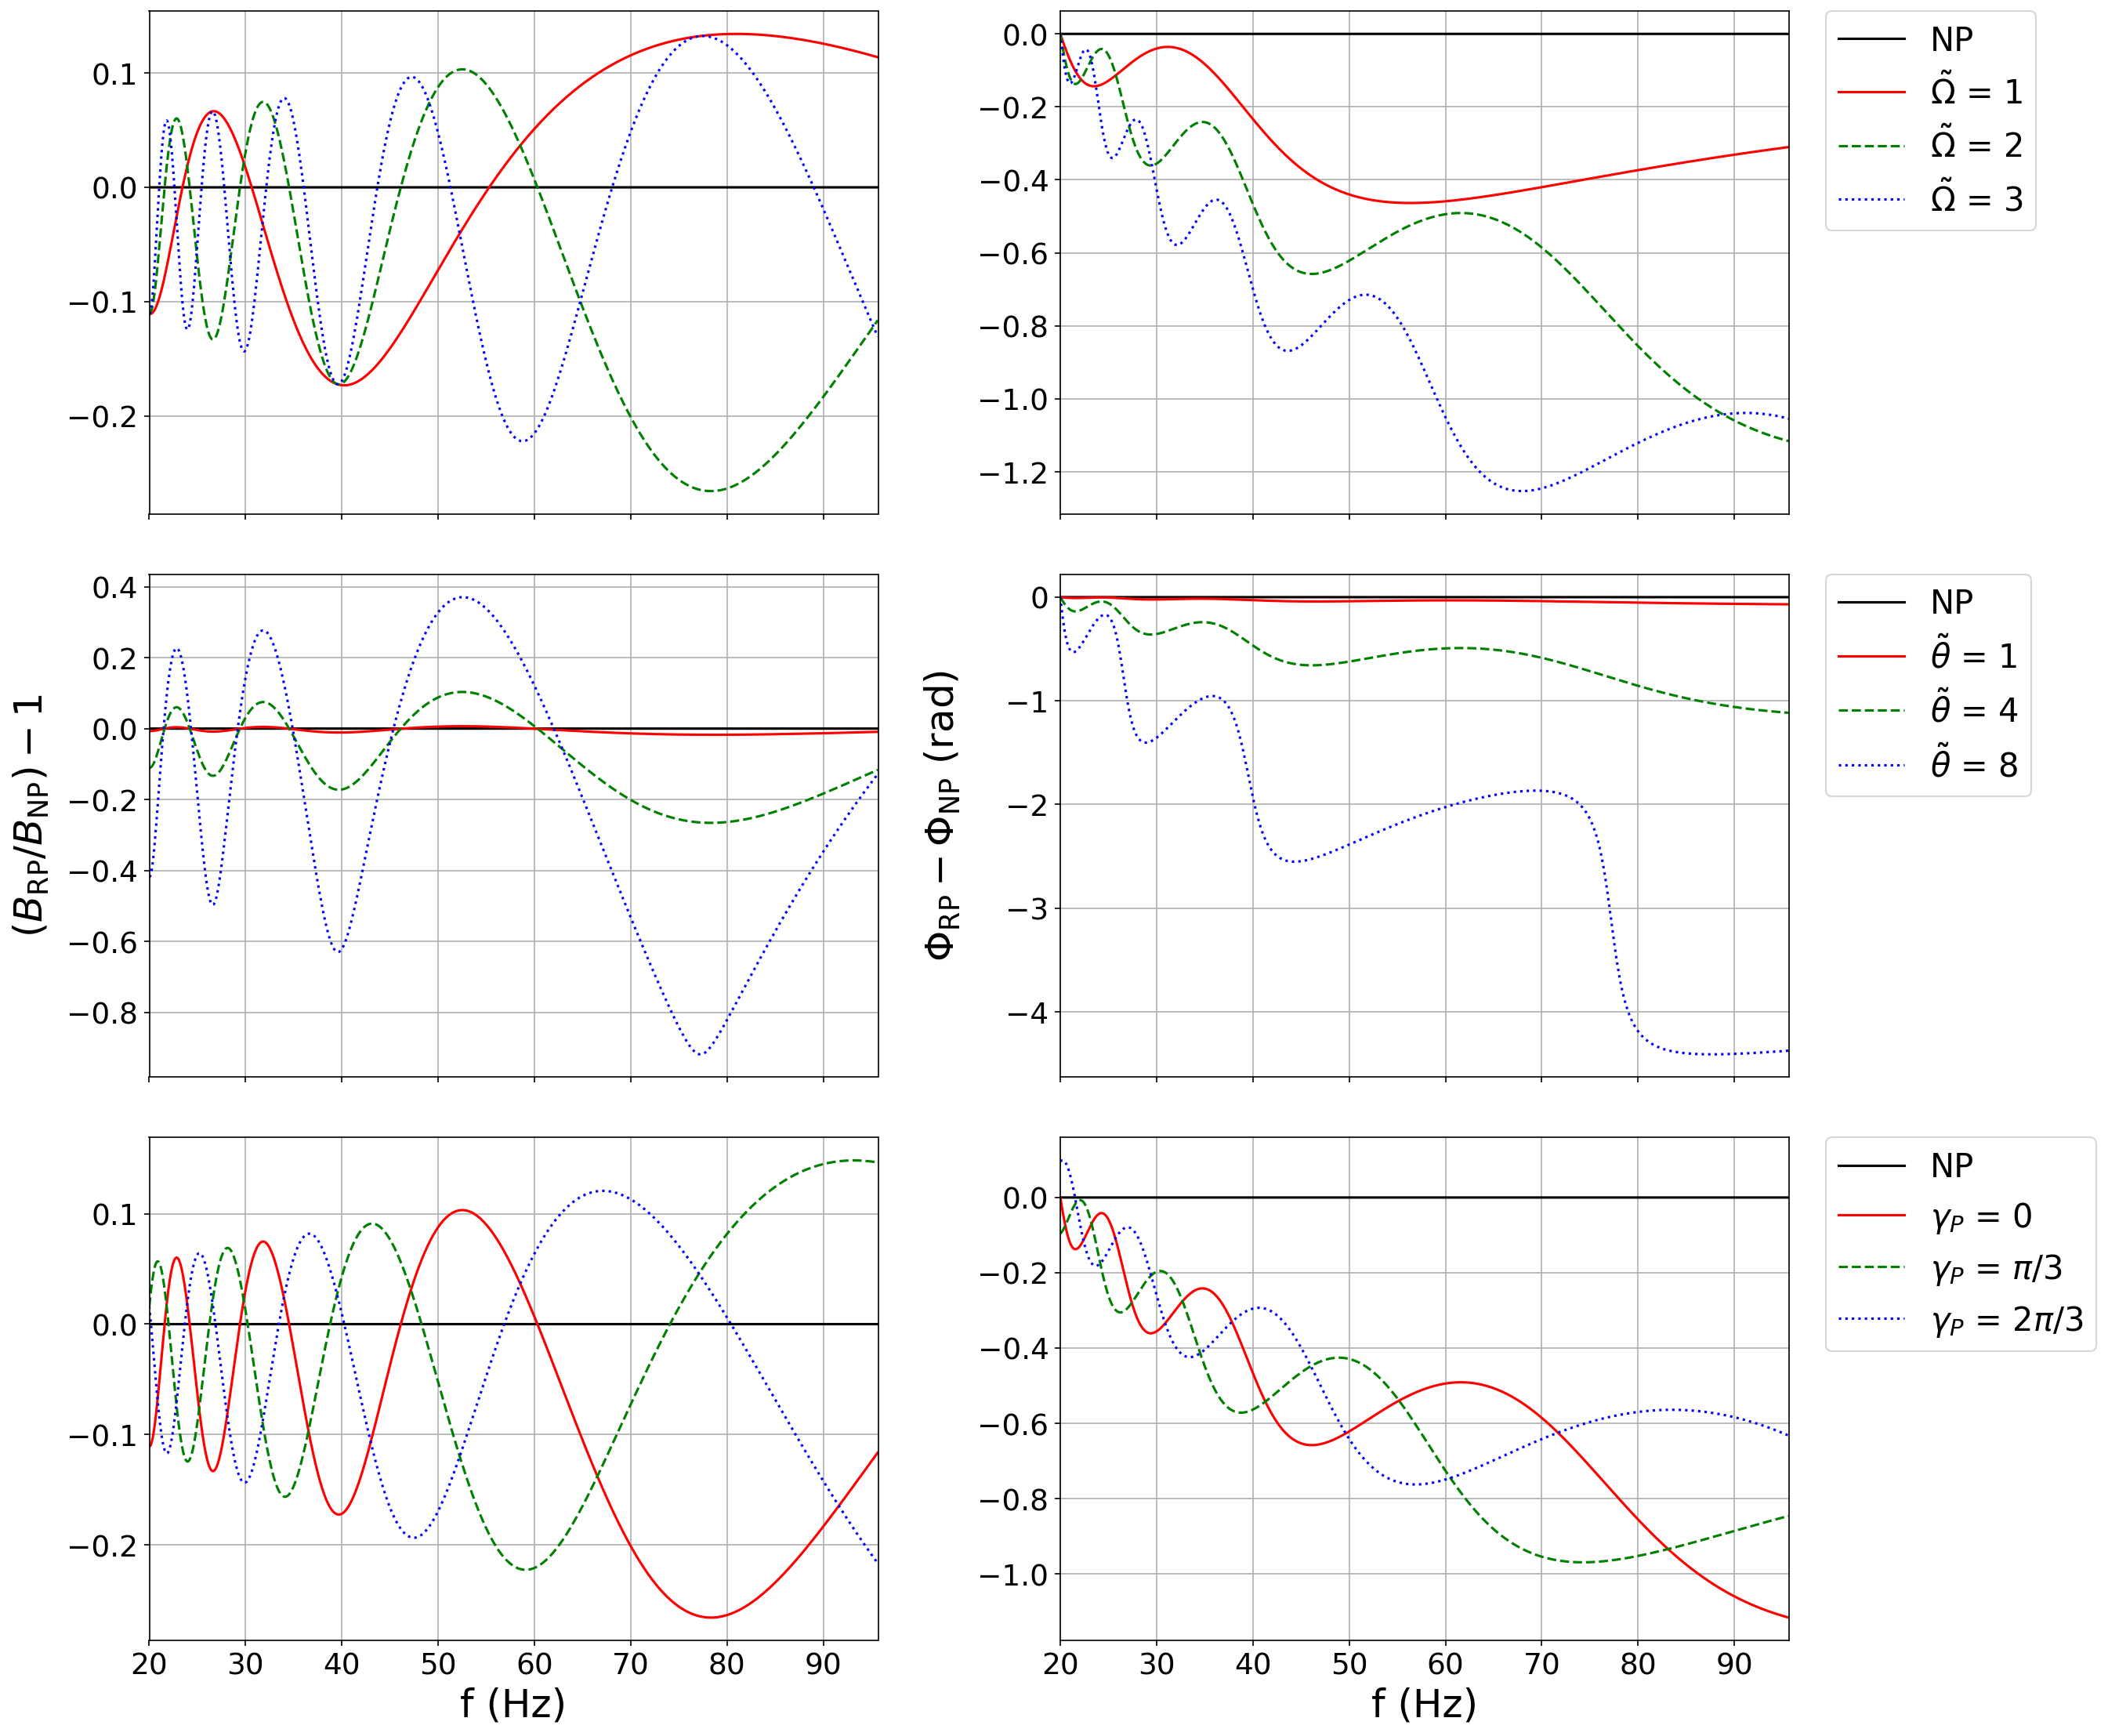

In [5]:
# Precessing (edge-on): amplitude ratio + phase
RP_params_1["mcz"] = NP_params_1["mcz"] = 10 * SOLMASS2SEC

fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    line_colors=linecolors,
    baseline_color="#000000",
    f_min=20,
    delta_f=0.05,
    z=1,
    save_path="../figures/waveforms/waveforms_RP_sys2.pdf",
)
print("system 2 in Taman's paper")

## face-on

Applied redshift z=0.0001 (mcz treated as source-frame)
system 1 in Taman's paper


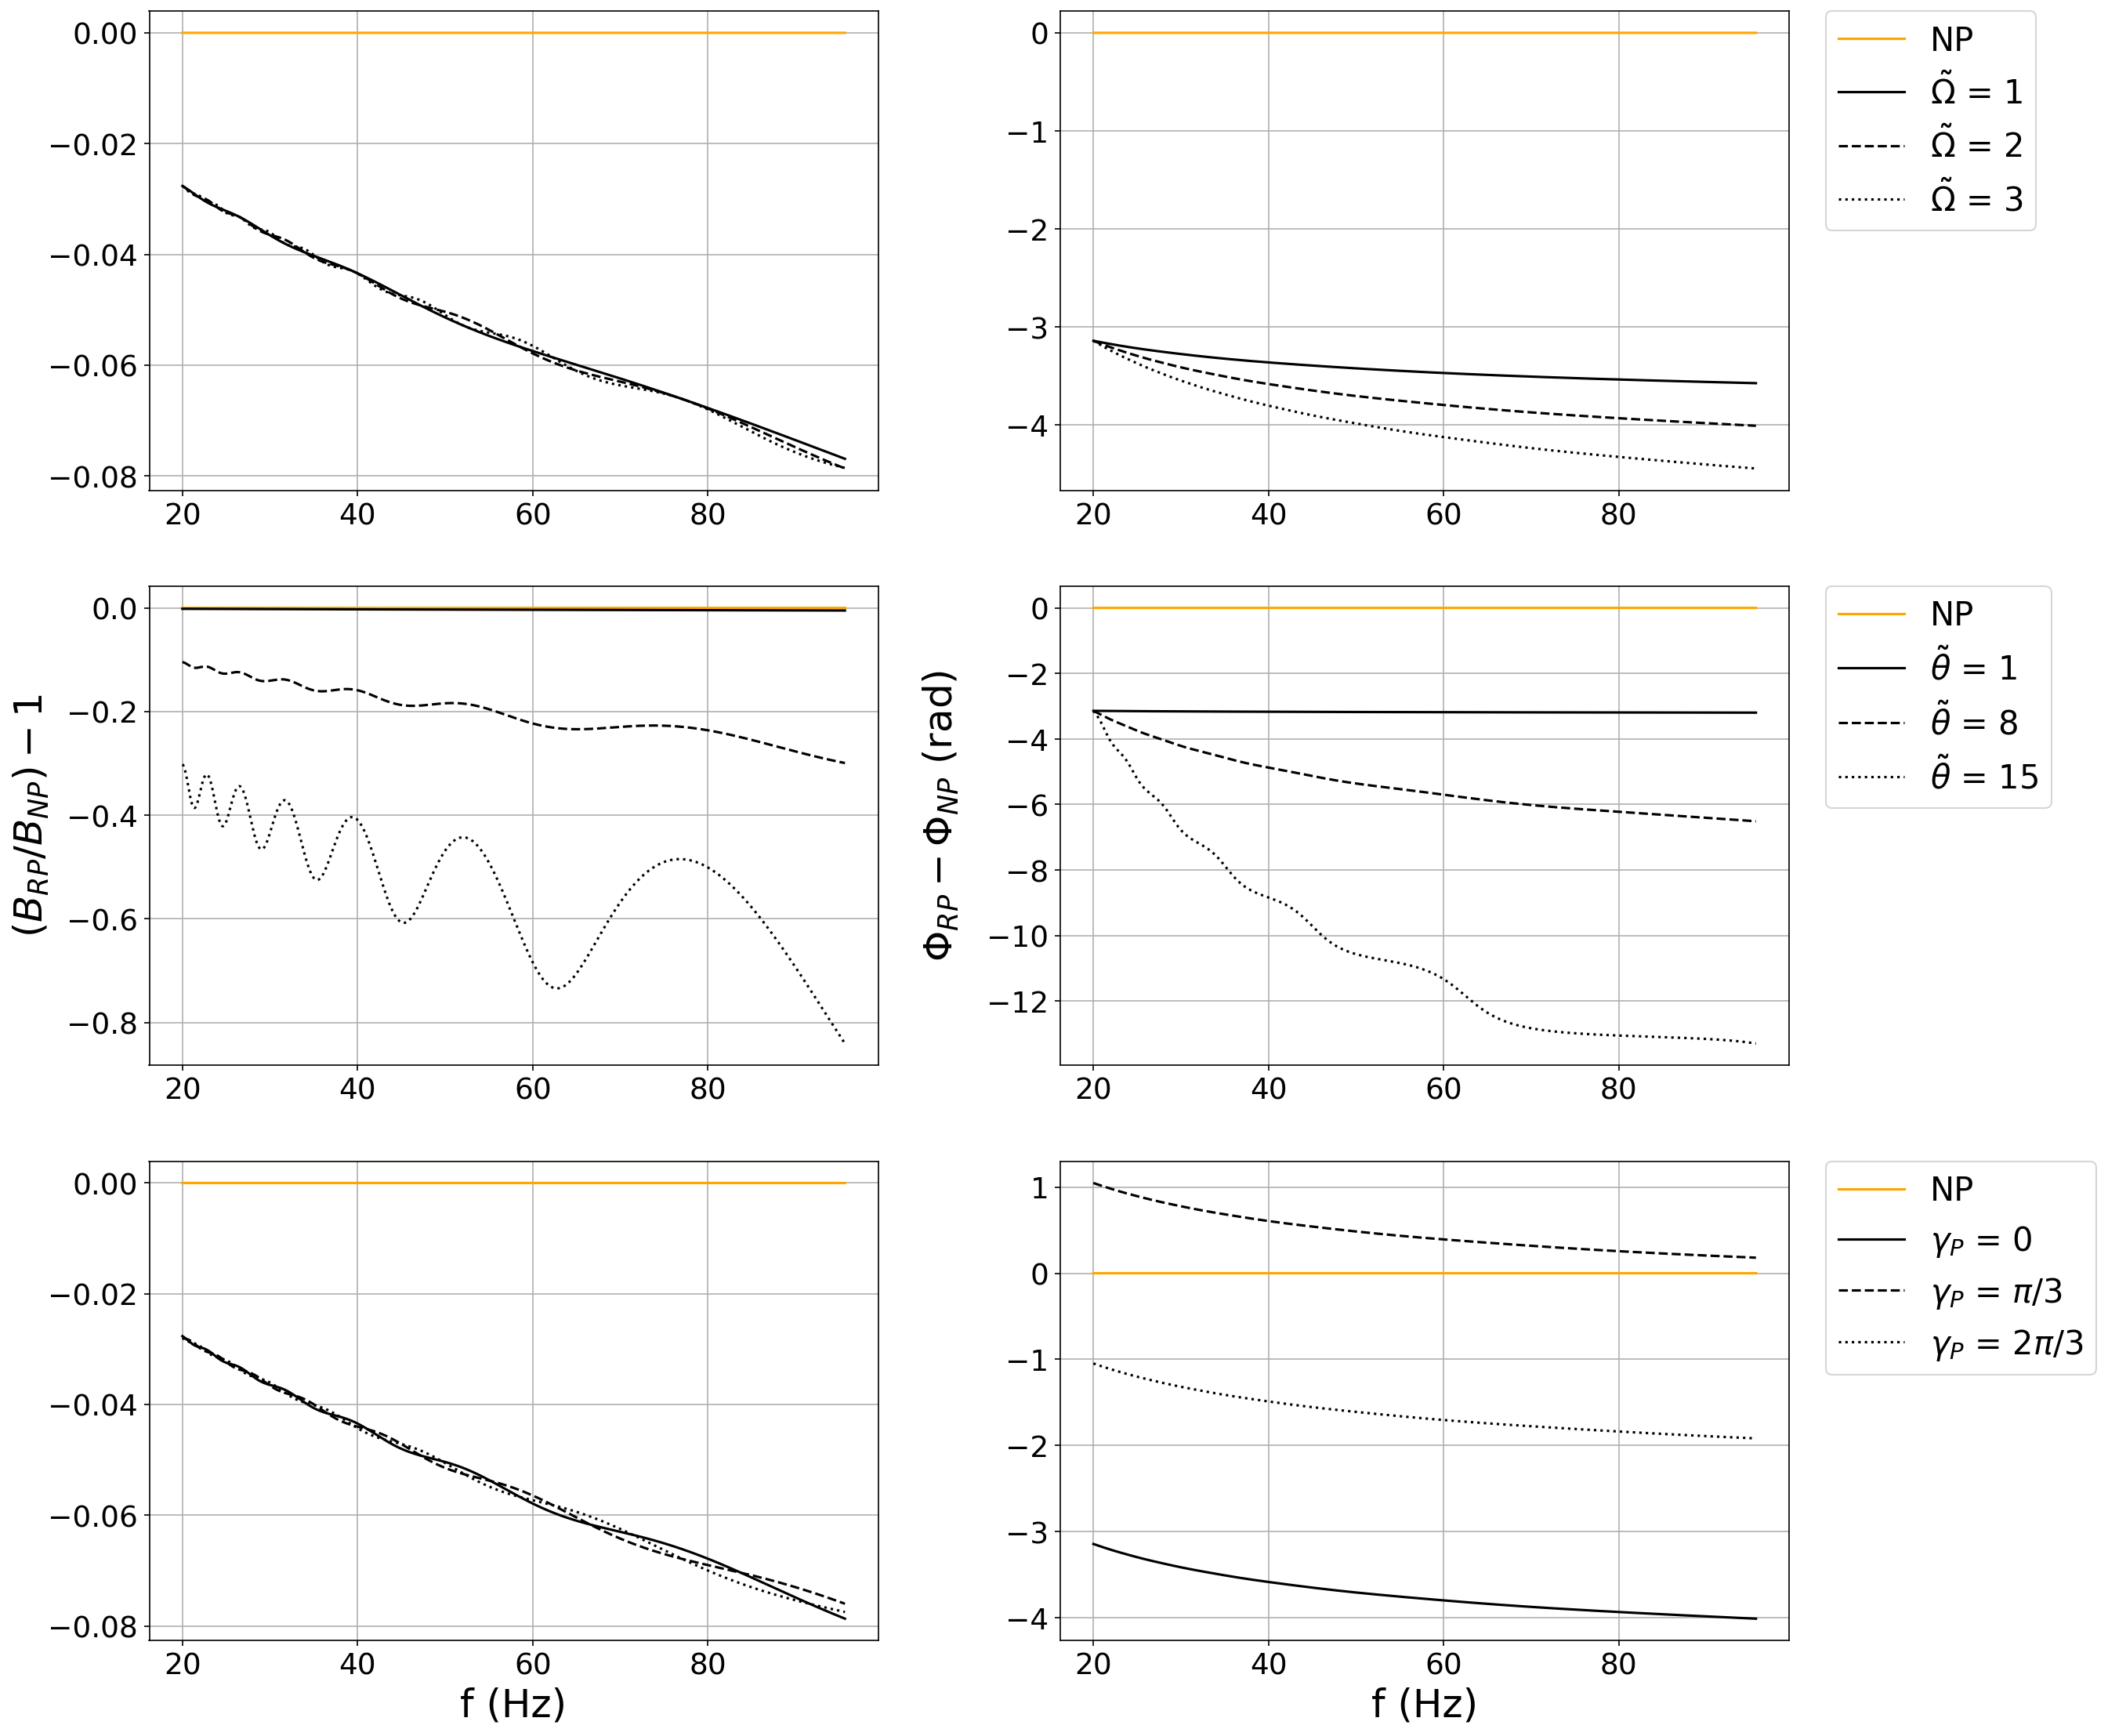

In [22]:
# Precessing (face-on): abs amplitude + phase
RP_params_1, NP_params_1 = set_orientation(
    loc_params["Taman"]["faceon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 8, 15]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=0.0001,
)
print("system 1 in Taman's paper")